Much information here is very specific to what I was doing but can serve as inspiration for future analysis.

Replace FILE LOCATION with a given file you want to check out.

In [ ]:
# load the python modules we will use
import uproot # for data loading
import awkward as ak # for data manipulation
import hist # for histogram filling (and some plotting)

import matplotlib as mpl # for plotting
import matplotlib.pyplot as plt # common shorthand
from matplotlib.colors import PowerNorm
import matplotlib.cm as cm
import mplhep # style of plots
%matplotlib inline
mpl.style.use(mplhep.style.ROOT) # set the plot style
import numpy as np
f"TriggerPadTracks: track position map"

print("\n".join(k for k in uproot.open("FILE LOCATION")["LDMX_Events"].keys()
               if any(x in k for x in ("Trigger","TrigScint","Pad")))) 
#Important keys for the TS


TriggerPad1SimHits_test
TriggerPad1SimHits_test/TriggerPad1SimHits_test.id_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.edep_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.x_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.y_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.z_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.time_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.track_id_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.incident_id_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.pdg_code_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.edep_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.time_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.origin_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.n_contribs_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.path_length_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.pre_step_x_
TriggerPad1SimHits_test/TriggerPad1SimHits_test.pre_step_y_
TriggerPad1SimHits_test/Tri

This is next cell is all about reading the files.

In [ ]:
from pathlib import Path


def _read_arrays(tree, branches, max_events=None):
    out = tree.arrays(branches, library="np")
    return {k: v[:max_events] for k, v in out.items()} if max_events is not None else out


def _merge_dicts(dicts):
    if not dicts:
        return {}
    return {k: sum((list(d[k]) for d in dicts), []) for k in dicts[0]}


CONFIG = { #keys that you want to analyze
    "test": {
        "sim_pat": "TriggerPad{pad}SimHits_test/TriggerPad{pad}SimHits_test.",
        "clu_pat": "TriggerPad{pad}Clusters_test/TriggerPad{pad}Clusters_test.",
        "dig_pat": "trigScintDigisPad{pad}_test/trigScintDigisPad{pad}_test.",
        "dig_keys": ["energy_", "xpos_", "ypos_", "zpos_", "time_", "is_noise_", "pe_", "bar_id_"],
        "track_bases": {
            "ftr": "TriggerPadTracks_test/TriggerPadTracks_test.",
            "Xtr": "TriggerPadTracksX_test/TriggerPadTracksX_test.",
            "Ytr": "TriggerPadTracksY_test/TriggerPadTracksY_test.",
        },
        "track_keys": ["x_", "y_", "z_", "centroid_", "centroid_x_", "centroid_y_", "sx_", "sy_","residual_x_"],
    },
    "overlay": {
        "sim_pat": "TriggerPad{pad}SimHitsOverlay_overlay/TriggerPad{pad}SimHitsOverlay_overlay.",
        "clu_pat": "TriggerPad{pad}Clusters_overlay/TriggerPad{pad}Clusters_overlay.",
        "dig_pat": "trigScintDigisPad{pad}_overlay/trigScintDigisPad{pad}_overlay.",
        "dig_keys": ["energy_", "xpos_", "ypos_", "zpos_", "time_", "is_noise_", "pe_"],
        "track_bases": {
            "ftr": "TriggerPadTracks_overlay/TriggerPadTracks_overlay.",
            "Xtr": "TriggerPadTracksX_overlay/TriggerPadTracksX_overlay.",
            "Ytr": "TriggerPadTracksY_overlay/TriggerPadTracksY_overlay.",
        },
        "track_keys": ["x_", "y_", "z_", "centroid_", "centroid_x_", "centroid_y_", "sx_", "sy_","residual_x_"],
    },
}


def load_ts(filename="events.root", pads=(1, 2, 3), max_events=None, mode="test"):
    if mode not in CONFIG: #function to read a file
        raise ValueError("mode must be 'test' or 'overlay'")

    cfg = CONFIG[mode]
    sim_keys = ["edep_", "x_", "y_", "z_", "time_", "n_contribs_"]
    clu_keys = ["energy_", "pe_", "centroid_x_", "centroid_y_", "centroid_z_", "time_", "n_hits_"]

    sim, clu, dig = {}, {}, {}

    with uproot.open(filename) as f:
        tree = f["LDMX_Events"]

        for pad in pads:
            sim[f"pad{pad}"] = _read_arrays(
                tree, [cfg["sim_pat"].format(pad=pad) + k for k in sim_keys], max_events
            )
            clu[f"pad{pad}"] = _read_arrays(
                tree, [cfg["clu_pat"].format(pad=pad) + k for k in clu_keys], max_events
            )
            dig[f"pad{pad}"] = _read_arrays(
                tree, [cfg["dig_pat"].format(pad=pad) + k for k in cfg["dig_keys"]], max_events
            )

        tracks = {
            name: _read_arrays(tree, [base + k for k in cfg["track_keys"]], max_events)
            for name, base in cfg["track_bases"].items()
        }

    return sim, clu, dig, tracks["ftr"], tracks["Xtr"], tracks["Ytr"]


def load_ts_folder(folder, pattern="*.root", pads=(1, 2, 3), max_events=None, mode="test"):
    files = sorted(Path(folder).glob(pattern)) #function to read a folder
    if not files:
        raise FileNotFoundError(f"No files matching {pattern} in {folder}")

    loaded = [load_ts(str(file), pads=pads, max_events=max_events, mode=mode) for file in files]
    all_sim, all_clu, all_dig, all_ftr, all_Xtr, all_Ytr = zip(*loaded)

    sim = {pad: _merge_dicts([d[pad] for d in all_sim]) for pad in all_sim[0]}
    clu = {pad: _merge_dicts([d[pad] for d in all_clu]) for pad in all_clu[0]}
    dig = {pad: _merge_dicts([d[pad] for d in all_dig]) for pad in all_dig[0]}

    return sim, clu, dig, _merge_dicts(all_ftr), _merge_dicts(all_Xtr), _merge_dicts(all_Ytr)

#mode test is for 1 electron and mode overlay is for multi electrons. Check
#your keys if you are not sure

sim, clu, dig, ftr, Xtr, Ytr = load_ts_folder(
        "1electron/baseline.v2",
    pattern="*.root",
    mode="test"
)

sim_alt, clu_alt, dig_alt, ftr_alt, Xtr_alt, Ytr_alt = load_ts_folder(
        "1electron/alternative.v2",
    pattern="*.root",
    mode="test"
)

sim_exp, clu_exp, dig_exp, ftr_exp, Xtr_exp, Ytr_exp = load_ts_folder(
        "1electron/experimental.v3",
    pattern="*.root",
    mode="test"
)
#Here I am reading three geometries: ldmx-det-v14-8gev and ldmx-vertTS-v14-8gev 
#(for no deviation and deviation in the last pad respectively). Check my config file 
#example on how to run it and my thesis on more about these geometries.

This section is for the X tracks. This is code is analyzing different parameters. A lot of it is just plotting. Change the plot.savefig for your specific location or delete/comment those lines.

Alternative geometry before redution:  13792
Alternative geometry before redution, x_min:  -99999.0
Alternative geometry after redution 12136
Alternative geometry centroid:  13792
Experimental geometry before redution, lenght of values:  15814
Experimental geometry before redution, x_min:  -99999.0
Experimental geometry after redution 13928
Experimental geometry centroid:  15814


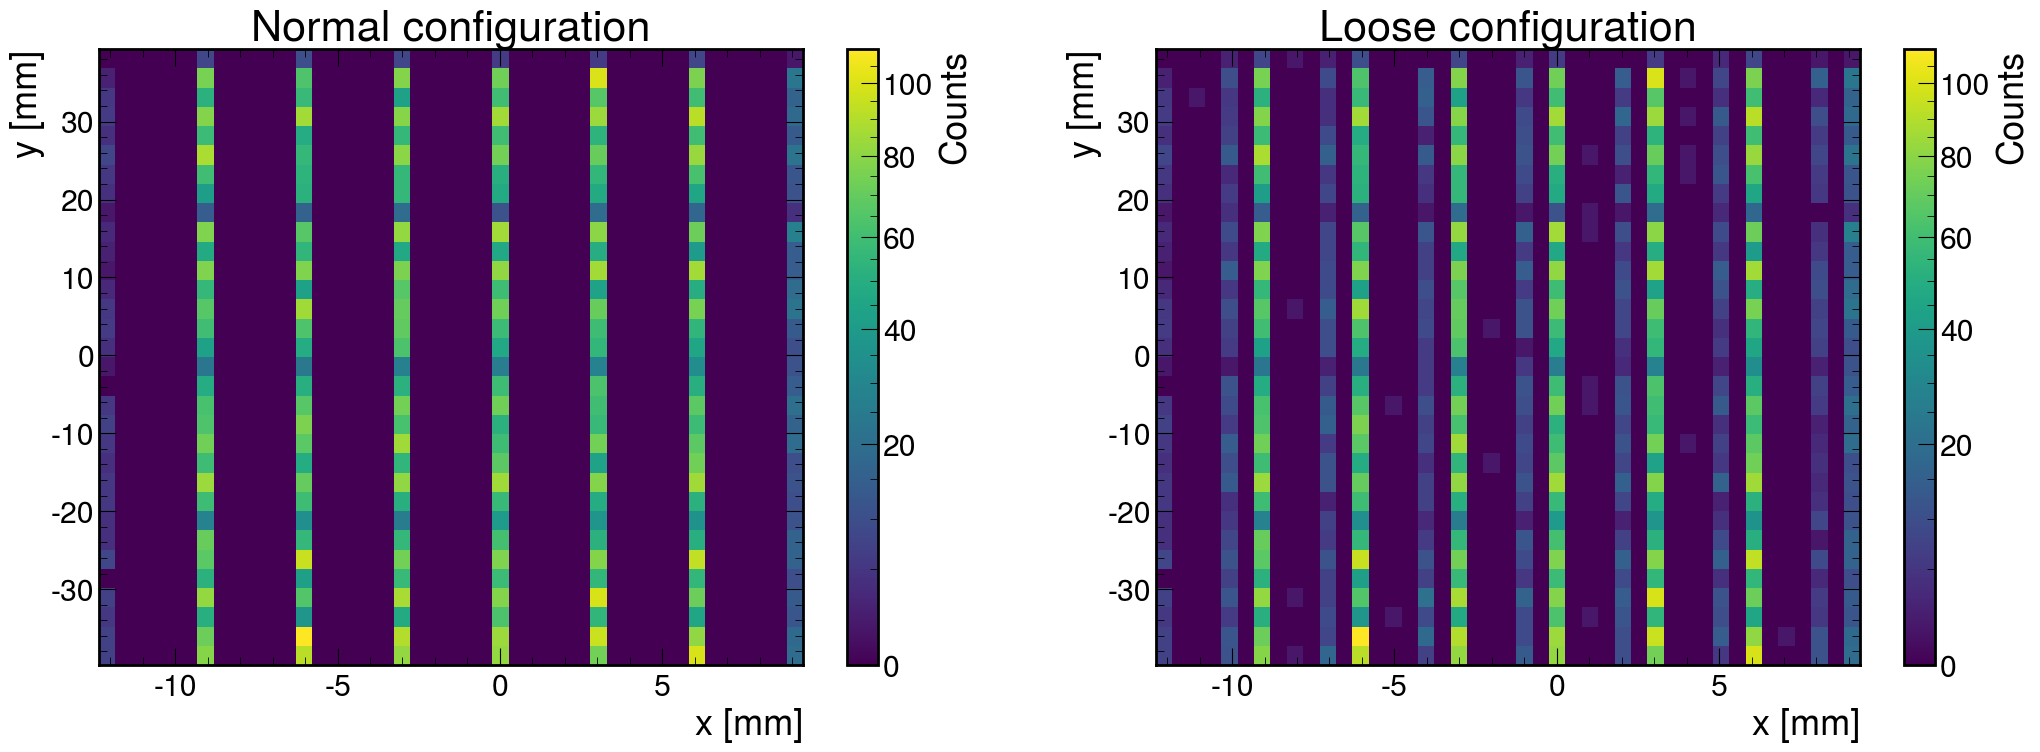

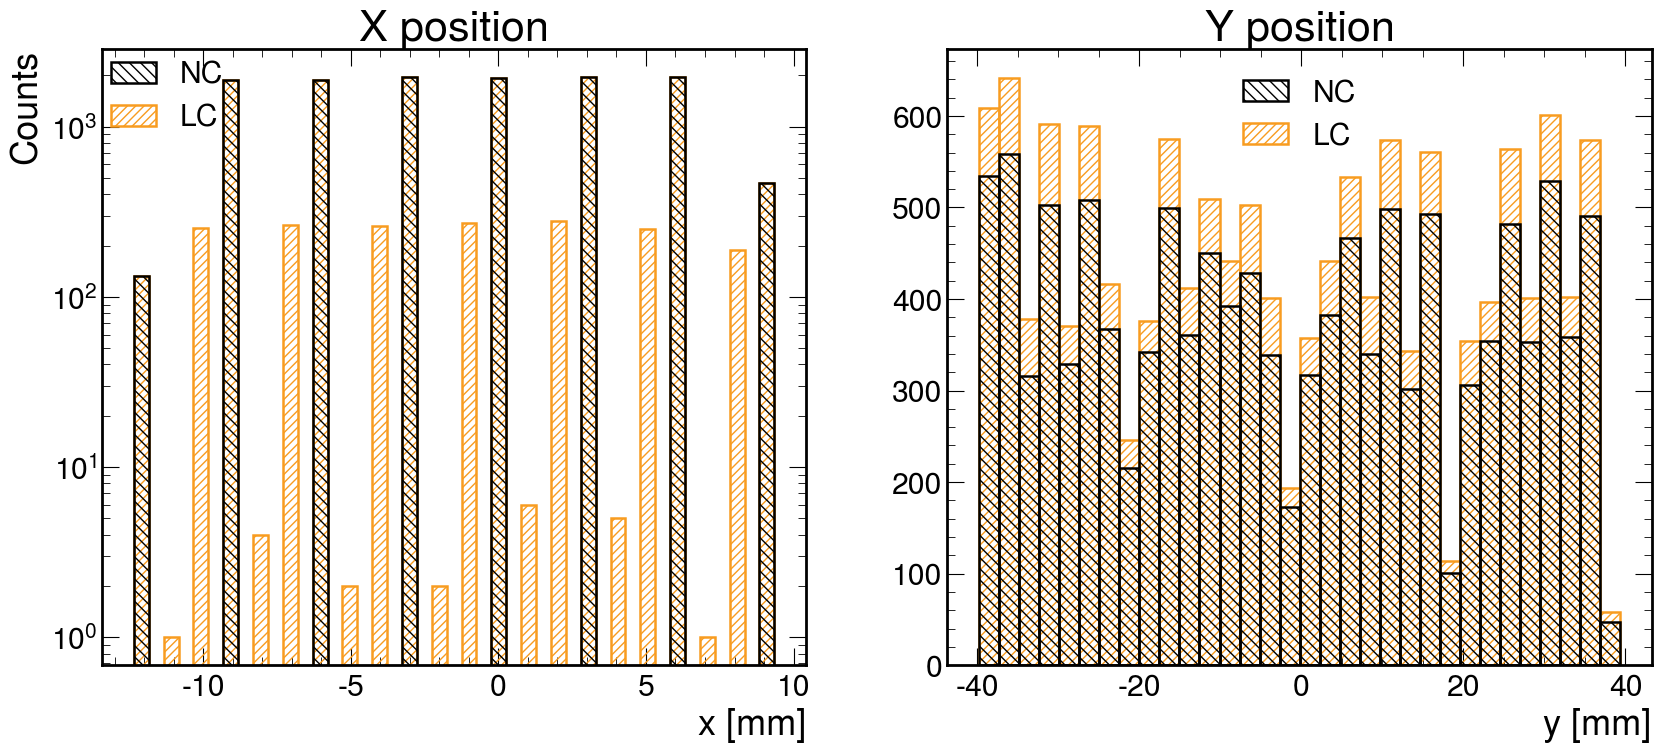

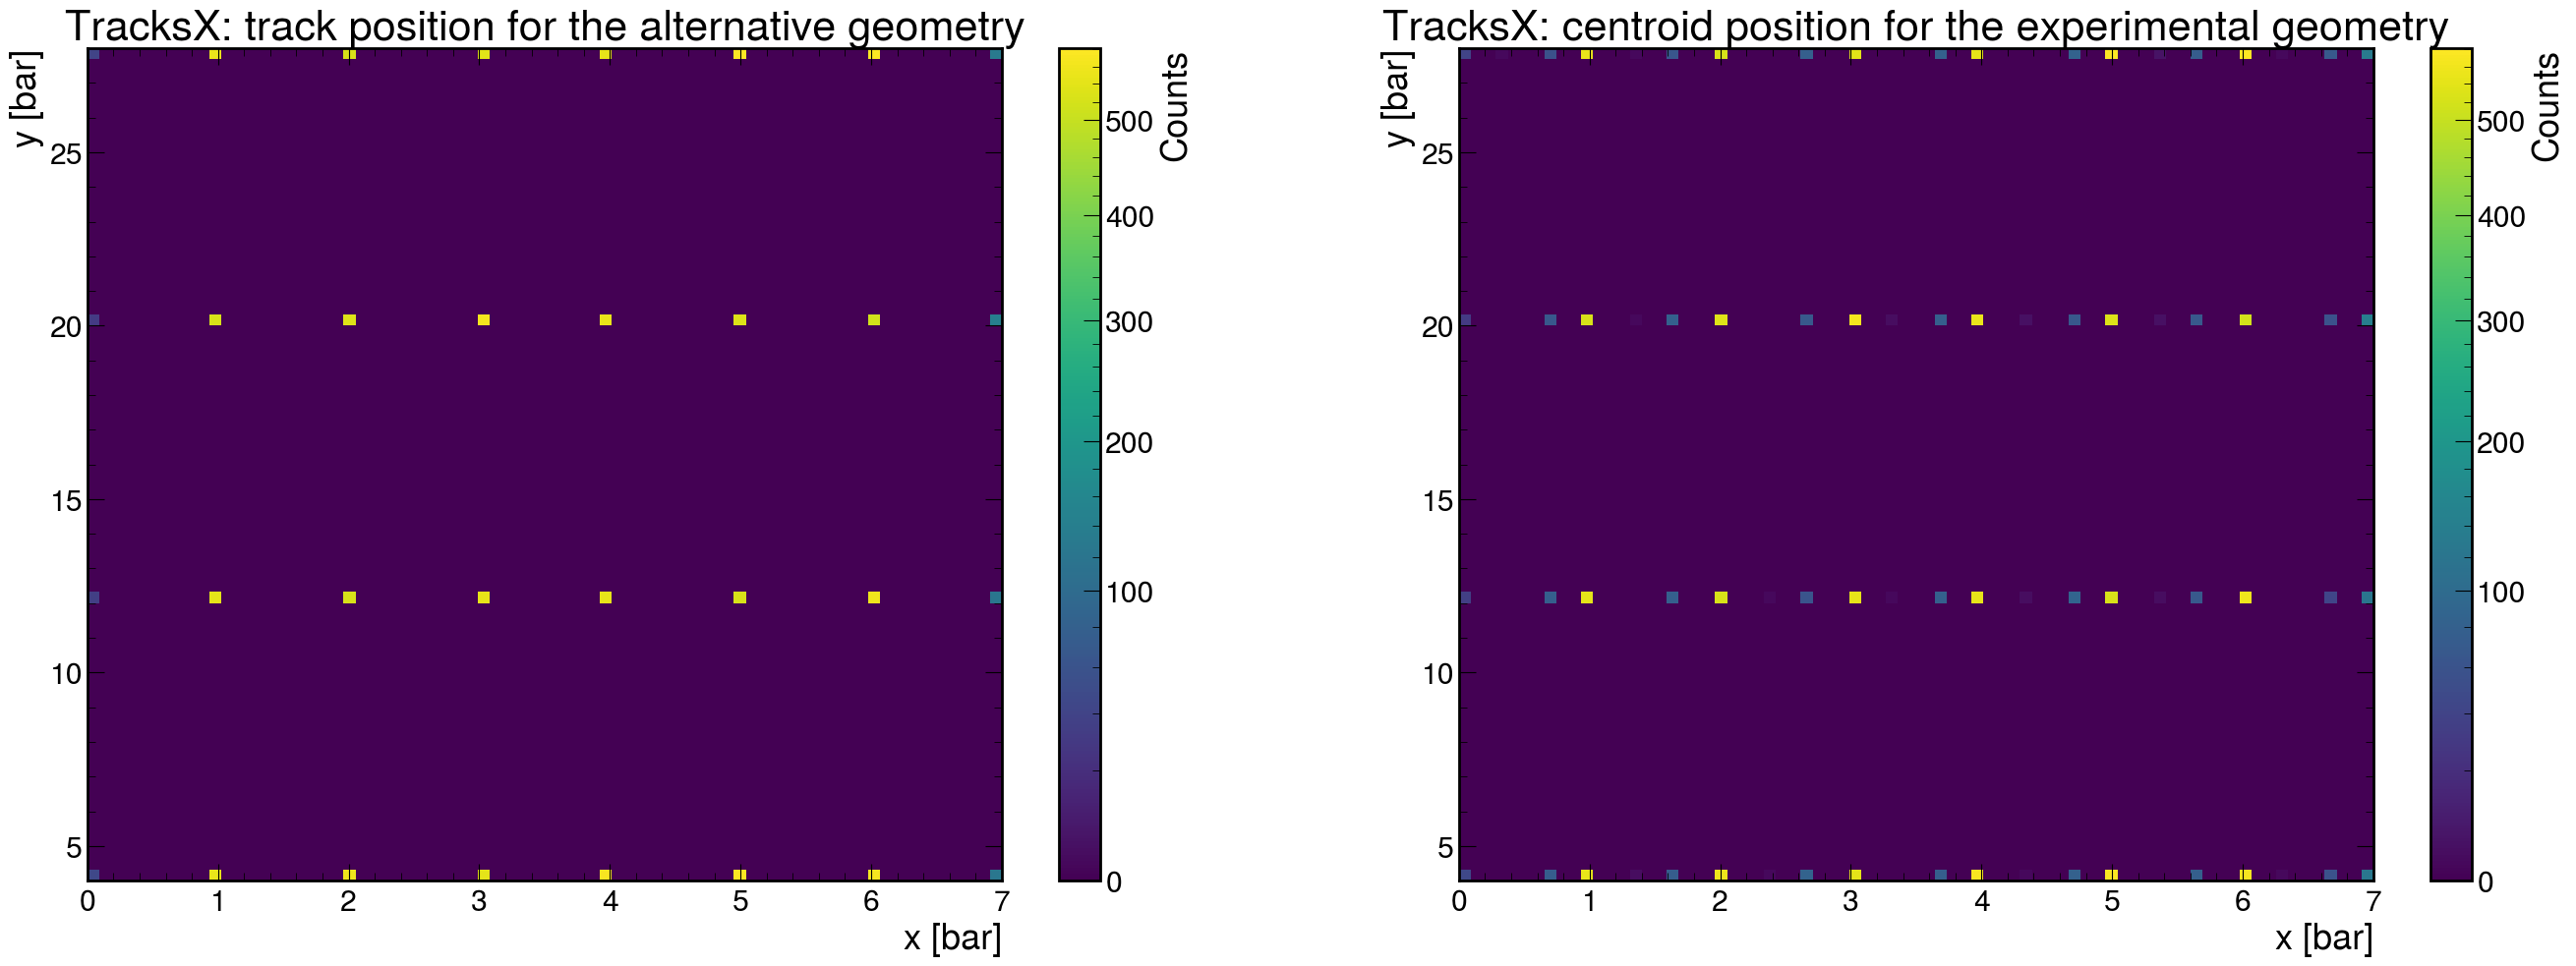

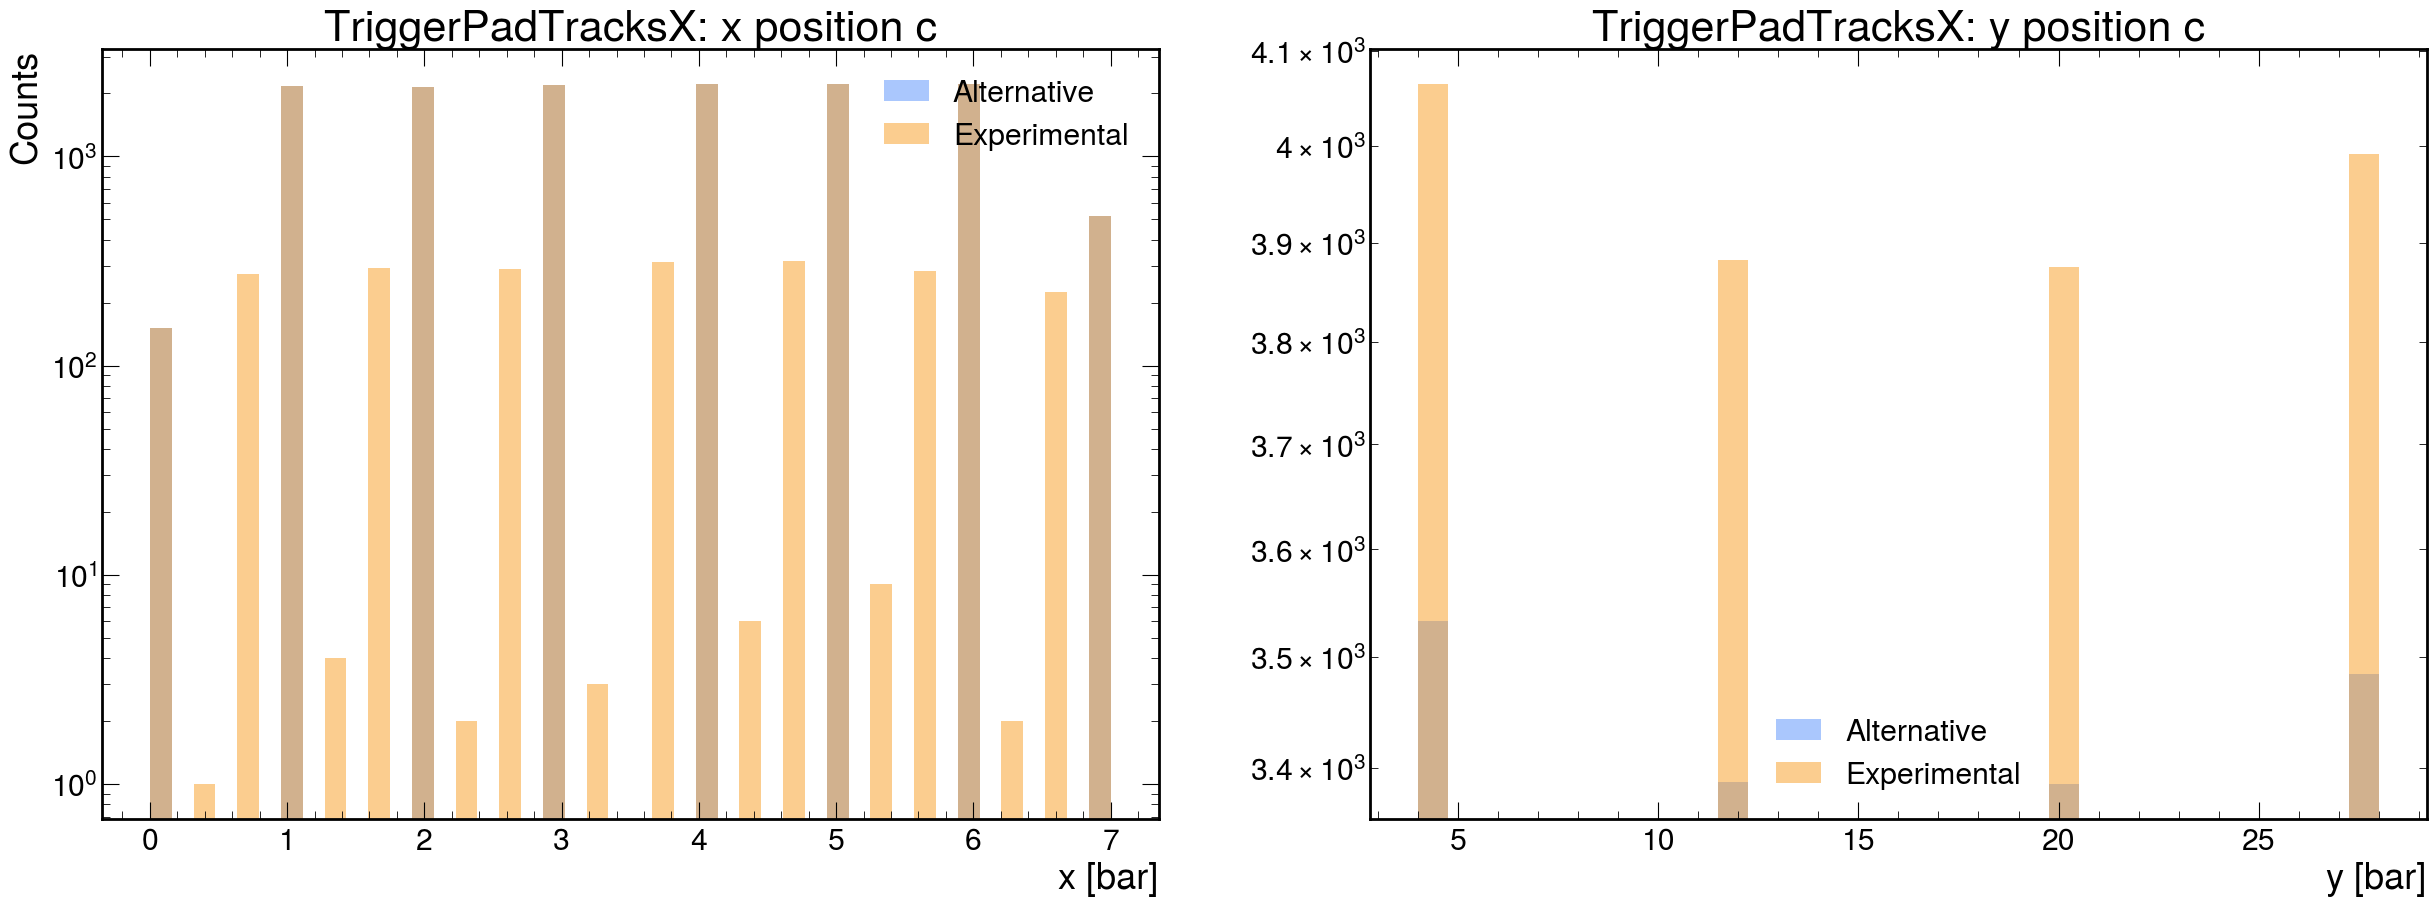

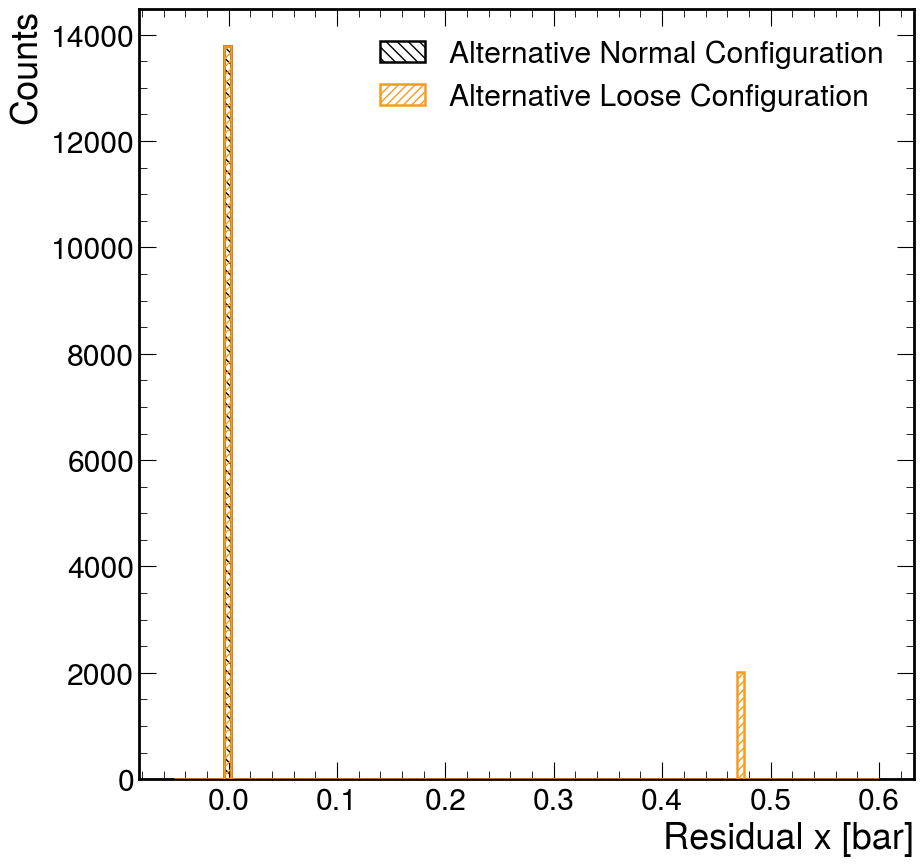

Alternative geometry before redution:  13792
Alternative geometry before redution, x_min:  -9999.0
Alternative geometry after redution 12136
Alternative geometry centroid:  12136
Experimental geometry before redution, lenght of values:  15814
Experimental geometry before redution, x_min:  -9999.0
Experimental geometry after redution, lenght of values 12136
Experimental geometry centroid:  12136


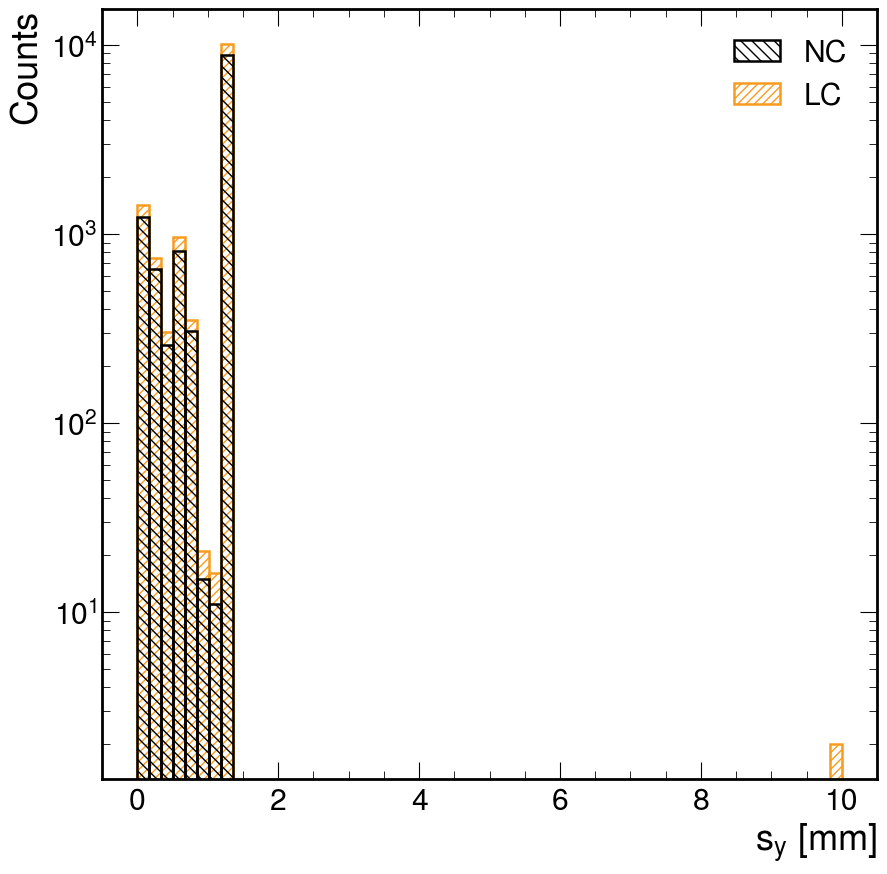

[9.9375 9.9375]
Alternative geometry: sx=(1.5499999523162842,1.5499999523162842) and sy=(0.0030127279460430145,1.3172695636749268)
Experimental geometry: sx=(1.5499999523162842,1.5499999523162842) and sy=(0.0030127279460430145,9.9375)


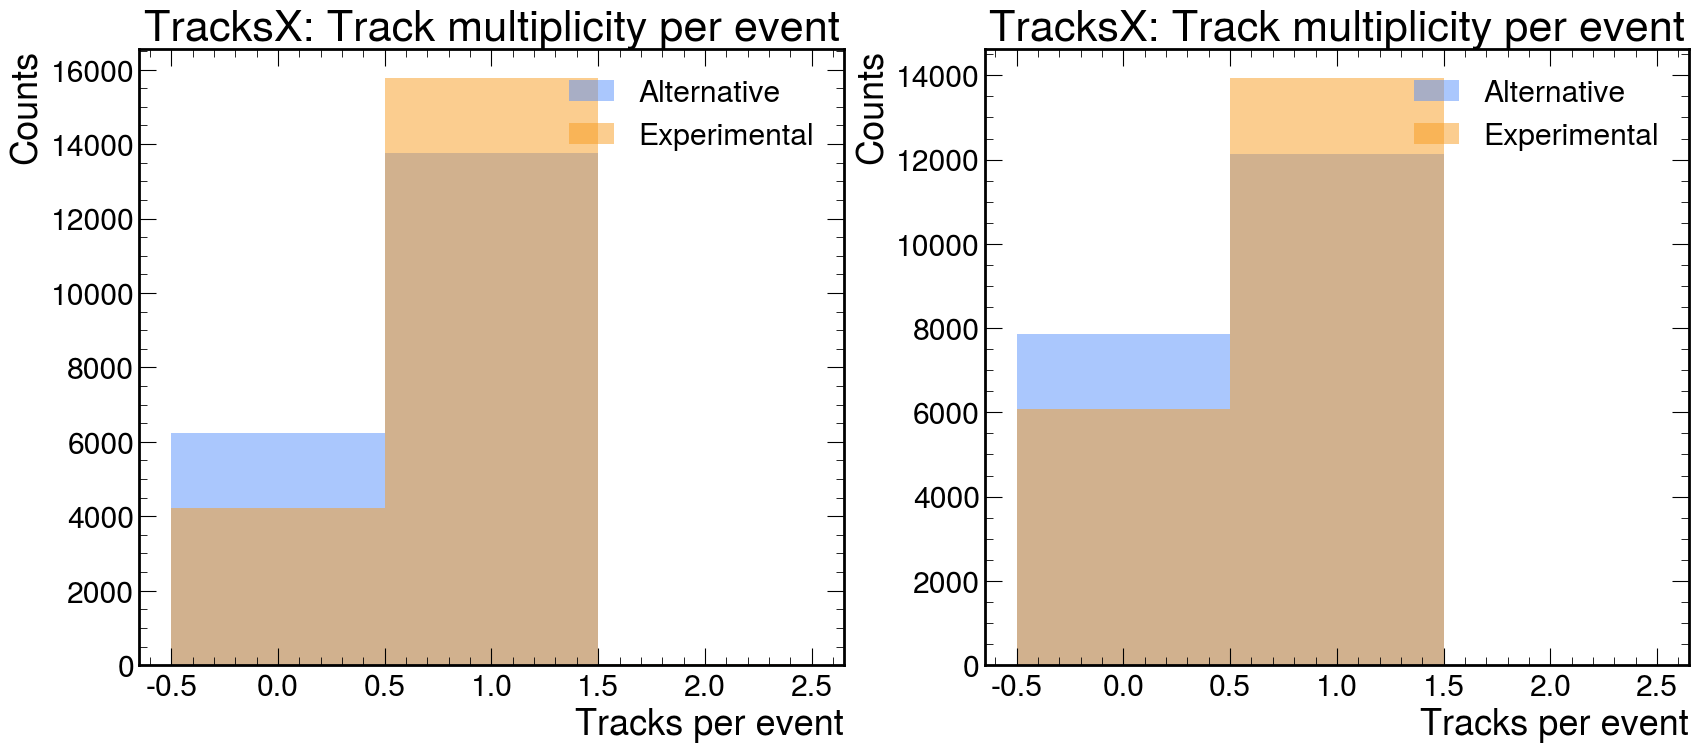

Number of 0-electron events:
- Alternative: 6228, 31.143 %
- Experimental: 4209, 21.047 %
Number of 1-electron events:
- Alternative: 13748, 68.747 %
- Experimental: 15764, 78.828 %
Number of 2-electron events:
- Alternative: 22, 0.110 %
- Experimental: 25, 0.125 %
Without alone Xtracks
Number of 0-electron events:
- Alternative: 7862, 39.314 %
- Experimental: 6071, 30.358 %
Number of 1-electron events:
- Alternative: 12136, 60.686 %
- Experimental: 13926, 69.637 %
Number of 2-electron events:
- Alternative: 0, 0.000 %
- Experimental: 1, 0.005 %



In [ ]:
def flatten_tracks(ftr_pad): #use this for test - 1 electron/event
    base = f"TriggerPadTracksX_test/TriggerPadTracksX_test."

    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])

    x = np.concatenate(ftr_pad[base+"x_"])
    y = np.concatenate(ftr_pad[base+"y_"])
    z = np.concatenate(ftr_pad[base+"z_"])
    xc = np.concatenate(ftr_pad[base+"centroid_x_"])
    yc = np.concatenate(ftr_pad[base+"centroid_y_"])
    sx = np.concatenate(ftr_pad[base+"sx_"])
    sy = np.concatenate(ftr_pad[base+"sy_"])
    c = np.concatenate(ftr_pad[base+"centroid_"])
    rx = np.concatenate(ftr_pad[base+"residual_x_"])

    # --- NEW: countTrue per event ---
    mask = (x >= -50)
    split_mask = np.split(mask, np.cumsum(count)[:-1])
    countTrue = np.array([np.sum(ev) for ev in split_mask])
    # --------------------------------

    return x, y, z, xc, yc, sx, sy, c, count, countTrue, rx

def flatten_tracks_(ftr_pad): #use this for overlay - multiple electron/event
    base = f"TriggerPadTracksX_overlay/TriggerPadTracksX_overlay."

    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])

    x = np.concatenate(ftr_pad[base+"x_"])
    y = np.concatenate(ftr_pad[base+"y_"])
    z = np.concatenate(ftr_pad[base+"z_"])
    xc = np.concatenate(ftr_pad[base+"centroid_x_"])
    yc = np.concatenate(ftr_pad[base+"centroid_y_"])
    sx = np.concatenate(ftr_pad[base+"sx_"])
    sy = np.concatenate(ftr_pad[base+"sy_"])
    rx = np.concatenate(ftr_pad[base+"residual_x_"])

    # --- NEW ---
    mask = (x >= -50)
    split_mask = np.split(mask, np.cumsum(count)[:-1])
    countTrue = np.array([np.sum(ev) for ev in split_mask])
    # ------------

    return x, y, z, xc, yc, sx, sy, count, countTrue, rx

x, y, z, xc, yc, sx, sy, c, count, countTrue,rx = flatten_tracks(Xtr) 
x_, y_, z_, xc_, yc_, sx_, sy_, c_,count_, countTrue_,rx_ = flatten_tracks(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,count_1, countTrue_1,rx_1 = flatten_tracks(Xtr_exp)

print("Alternative geometry before redution: ",len(x_))

print("Alternative geometry before redution, x_min: ",min(x_))
# Update to eliminate "bad points"
mn = -50
y_ = y_[y_ >= mn]
x_ = x_[(x_ >=mn) ]
print("Alternative geometry after redution", len(x_))
print("Alternative geometry centroid: ",len(xc_))

print("Experimental geometry before redution, lenght of values: ",len(x_1))

print("Experimental geometry before redution, x_min: ",min(x_1))
# Update to eliminate "bad points"
mn = -50
y_1 = y_1[y_1 >= mn]
x_1 = x_1[(x_1 >=mn) ]
print("Experimental geometry after redution", len(x_1))
print("Experimental geometry centroid: ",len(xc_1))


fig, axs = plt.subplots(1, 2, figsize=(25,8))
h0 = axs[0].hist2d(x_, y_, bins=(43,32),norm=PowerNorm(gamma=0.6))
axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
axs[0].set_title(f"Normal configuration")

h1 = axs[1].hist2d(x_1, y_1, bins=(43,32),norm=PowerNorm(gamma=0.6))
axs[1].set_xlabel("x [mm]")
axs[1].set_ylabel("y [mm]")
axs[1].set_title(f"Loose configuration")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")
# fig.suptitle("TracksX: 2D Map for 1 electron/event")#, fontsize=18)
plt.savefig('plots/1elec/TracksX_position2D', dpi=300, bbox_inches="tight")
#plt.tight_layout() do not works with both
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20,8))

axs[0].hist(x_, bins=43, histtype='bar', facecolor='none', edgecolor='black',
            hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='NC')

axs[0].hist(x_1, bins=43, histtype='bar', facecolor='none', edgecolor='C1',
            hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='LC')
axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"X position")
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.03,1.03))

axs[1].hist(y_, bins=32, histtype='bar', facecolor='none', edgecolor='black',
            hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3, label='NC')
axs[1].hist(y_1, bins=32, histtype='bar', facecolor='none', edgecolor='C1',
            hatch='////', linewidth=1.8, alpha=1, zorder=2, label='LC')
axs[1].set_xlabel("y [mm]")
axs[1].set_title(f"Y position")
axs[1].legend()
# fig.suptitle("TracksX: Position comparasion for 1 electron/event")
plt.savefig('plots/1elec/TracksX_position1D', dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(33,11))
h0 = axs[0].hist2d(xc_, yc_, bins=75,norm=PowerNorm(gamma=0.6))
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("y [bar]")
axs[0].set_title(f"TracksX: track position for the alternative geometry")

h1 = axs[1].hist2d(xc_1, yc_1, bins=75,norm=PowerNorm(gamma=0.6))
axs[1].set_xlabel("x [bar]")
axs[1].set_ylabel("y [bar]")
axs[1].set_title(f"TracksX: centroid position for the experimental geometry")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")   
#plt.tight_layout() do not works with both
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(30,10))

axs[0].hist(xc_,  bins=44, alpha=0.5, label='Alternative')
axs[0].hist(xc_1, bins=44, alpha=0.5, label='Experimental')
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"TriggerPadTracksX: x position c")
axs[0].legend()

axs[1].hist(yc_,  bins=32, alpha=0.5, label='Alternative')
axs[1].hist(yc_1, bins=32, alpha=0.5, label='Experimental')
axs[1].set_xlabel("y [bar]")
axs[1].set_yscale('log')
axs[1].set_title(f"TriggerPadTracksX: y position c")
axs[1].legend()

#plt.tight_layout()
plt.show()

plt.figure()
bins=np.linspace(-0.05,0.6,100)
plt.hist(rx_, bins=bins, histtype='bar', facecolor='none', edgecolor='black',
            hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3, 
         label='Alternative Normal Configuration')
plt.hist(rx_1, bins=bins, histtype='bar', facecolor='none', edgecolor='C1',
            hatch='////', linewidth=1.8, alpha=1, zorder=3, 
         label='Alternative Loose Configuration')
plt.xlabel("Residual x [bar]")
plt.ylabel("Counts")
plt.legend()
plt.savefig('plots/1elec/TracksX_rx', dpi=300, bbox_inches="tight")
plt.show()


print("Alternative geometry before redution: ",len(sx_))

print("Alternative geometry before redution, x_min: ",min(sx_))
# Update to eliminate "bad points"
mn = -50
sy_ = sy_[sy_ >= mn]
sx_ = sx_[(sx_ >=mn) ]
print("Alternative geometry after redution", len(sx_))
print("Alternative geometry centroid: ",len(sx_))

print("Experimental geometry before redution, lenght of values: ",len(sx_1))

print("Experimental geometry before redution, x_min: ",min(sx_1))
# Update to eliminate "bad points"
mn = -50
sy_1 = sy_1[sy_1 >= mn]
sx_1 = sx_1[(sx_1 >=mn) ]
print("Experimental geometry after redution, lenght of values", len(sx_))
print("Experimental geometry centroid: ",len(sx_))

# fig, axs = plt.subplots(1, 2, figsize=(20,8))

# axs[0].hist(sx_,  bins='auto', alpha=0.5, label='Alternative')
# axs[0].hist(sx_1, bins='auto', alpha=0.5, label='Experimental')
# axs[0].set_xlabel("sx [mm]")
# axs[0].set_ylabel("Counts")
# axs[0].set_yscale('log')
# axs[0].set_title(f"TriggerPadTracksX: sx")
# axs[0].legend()

# axs[1].hist(sy_,  bins='auto', alpha=0.5, label='Alternative')
# axs[1].hist(sy_1, bins='auto', alpha=0.5, label='Experimental')
# axs[1].set_xlabel("sy [mm]")
# axs[1].set_ylabel("Counts")
# axs[1].set_yscale('log')
# axs[1].set_title(f"TriggerPadTracksX: sy")
# axs[1].legend()

# #plt.tight_layout()
# plt.show()

bins=np.linspace(0,10,60)
plt.figure()
plt.hist(sy_, bins=bins, histtype='bar', facecolor='none', edgecolor='black',
         hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
         label='NC')

plt.hist(sy_1, bins=bins, histtype='bar', facecolor='none', edgecolor='C1',
         hatch='////', linewidth=1.8, alpha=1, zorder=2,
         label='LC')
plt.xlabel("$s_y$ [mm]")
plt.ylabel("Counts")
plt.yscale('log')
# plt.title(f"TracksX: Uncertainty $s_y$ comparasion for 2 electrons/event")
plt.legend()
plt.savefig('plots/1elec/TracksX_uncertaintyY', dpi=300, bbox_inches="tight")
plt.show()

print(sy_1[sy_1>9])
text= f"""Alternative geometry: sx=({min(sx_)},{max(sx_)}) and sy=({min(sy_)},{max(sy_)})
Experimental geometry: sx=({min(sx_1)},{max(sx_1)}) and sy=({min(sy_1)},{max(sy_1)})"""

print(text)

# Define bins centered on integers
max_count = int(max(count.max(), count_.max(),count_1.max()))
bins = np.arange(-0.5, max_count + 1.5, 1)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(20,8))

# plt.hist(count,  bins=bins, alpha=0.5, label='Baseline')#,density=True)
axs[0].hist(count_, bins=bins, alpha=0.5, label='Alternative')#,density=True)
axs[0].hist(count_1, bins=bins, alpha=0.5, label='Experimental')#,density=True)
axs[0].set_xlabel("Tracks per event")
axs[0].set_ylabel("Counts")
# plt.yscale('log')
axs[0].set_title("TracksX: Track multiplicity per event")
axs[0].legend()
# plt.hist(count,  bins=bins, alpha=0.5, label='Baseline')#,density=True)
axs[1].hist(countTrue_, bins=bins, alpha=0.5, label='Alternative')#,density=True)
axs[1].hist(countTrue_1, bins=bins, alpha=0.5, label='Experimental')#,density=True)
axs[1].set_xlabel("Tracks per event")
axs[1].set_ylabel("Counts")
# plt.yscale('log')
axs[1].set_title("TracksX: Track multiplicity per event")
axs[1].legend()
plt.show()

text = f"""Number of 0-electron events:
- Alternative: {np.sum(count_ == 0)}, {np.sum(count_==0)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 0)}, {np.sum(count_1==0)*100/len(count_1):.3f} %
Number of 1-electron events:
- Alternative: {np.sum(count_ == 1)}, {np.sum(count_==1)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 1)}, {np.sum(count_1==1)*100/len(count_1):.3f} %
Number of 2-electron events:
- Alternative: {np.sum(count_ == 2)}, {np.sum(count_==2)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 2)}, {np.sum(count_1==2)*100/len(count_1):.3f} %
Without alone Xtracks
Number of 0-electron events:
- Alternative: {np.sum(countTrue_ == 0)}, {np.sum(countTrue_==0)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 0)}, {np.sum(countTrue_1==0)*100/len(countTrue_1):.3f} %
Number of 1-electron events:
- Alternative: {np.sum(countTrue_ == 1)}, {np.sum(countTrue_==1)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 1)}, {np.sum(countTrue_1==1)*100/len(countTrue_1):.3f} %
Number of 2-electron events:
- Alternative: {np.sum(countTrue_ == 2)}, {np.sum(countTrue_==2)*100/len(countTrue_):.3f} %
- Experimental: {np.sum(countTrue_1 == 2)}, {np.sum(countTrue_1==2)*100/len(countTrue_1):.3f} %
"""

print(text)

This next section is about looking for specific things in the arrays.

In [19]:
x_, y_, z_, xc_, yc_, sx_, sy_, c_,count_, countTrue_,rx_ = flatten_tracks(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,count_1, countTrue_1,rx_1 = flatten_tracks(Xtr_exp)
mn = -50
sy_ = sy_[sy_ >= mn]
sx_ = sx_[(sx_ >=mn) ]
sy_1 = sy_1[sy_1 >= mn]
sx_1 = sx_1[(sx_1 >=mn) ]
text = f"""- Alternative geometry
sx={np.mean(sx_):.2f}
sy={np.mean(sy_):.2f}

 - Experimental geometry
sx={np.mean(sx_1):.2f}
sy={np.mean(sy_1):.2f}
"""
print(text)

- Alternative geometry
sx=1.55
sy=1.02

 - Experimental geometry
sx=1.55
sy=1.02



 - Alternative geometry
Length of values: 1656
event_id: [   10    13    27 ... 19980 19985 19993]
x: [-99999. -99999. -99999. ... -99999. -99999. -99999.]
y: [-99999. -99999. -99999. ... -99999. -99999. -99999.]
xc: [5. 1. 4. ... 1. 5. 1.]
yc: [ 4. 20. 12. ... 20. 20. 28.]
sx: [-9999. -9999. -9999. ... -9999. -9999. -9999.]
sy:[-9999. -9999. -9999. ... -9999. -9999. -9999.]
r: [0. 0. 0. ... 0. 0. 0.]

 - Experimental geometry
Length of values: 1886
event_id: [   10    13    27 ... 19985 19992 19993]
x: [-99999. -99999. -99999. ... -99999. -99999. -99999.]
y: [-99999. -99999. -99999. ... -99999. -99999. -99999.]
xc: [5.        1.        4.        ... 5.        6.6666665 1.       ]
yc: [ 4. 20. 12. ... 20. 28. 28.]
sx: [-9999. -9999. -9999. ... -9999. -9999. -9999.]
sy:[-9999. -9999. -9999. ... -9999. -9999. -9999.]
r: [0.         0.         0.         ... 0.         0.47140452 0.        ]



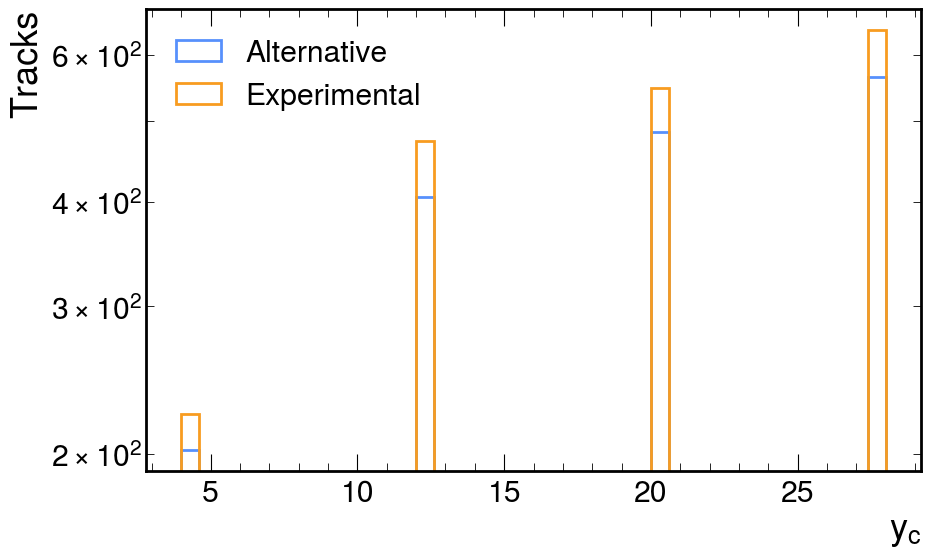

In [ ]:
# Analyse for -9999 values
x_, y_, z_, xc_, yc_, sx_, sy_, c_,count_, countTrue_,rx_ = flatten_tracks(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1,countTrue_1, rx_1 = flatten_tracks(Xtr_exp)

event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# Build x mask 
target_x = -99  
track_mask_ = (x_ < target_x) 
track_mask_1 = (x_1 < target_x)

event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

x_, y_, z_, xc_, yc_, sx_, sy_, c_ ,rx_= [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_,rx_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,rx_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,rx_1)]

text = f""" - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}\nr: {rx_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}\nr: {rx_1}
"""
print(text)

bins = np.linspace(
    min(yc_.min(), yc_1.min()),
    max(yc_.max(), yc_1.max()),
    40
)

plt.figure(figsize=(10, 6))

plt.hist(
    yc_,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Alternative"
)

plt.hist(
    yc_1,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Experimental"
)

plt.xlabel(r"$y_c$")
plt.ylabel("Tracks")
plt.yscale("log")
plt.legend()

plt.savefig(
    "plots/yc_hist_x_missing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Analyse for -9999 values
x_, y_, z_, xc_, yc_, sx_, sy_, c_,count_, countTrue_,rx_ = flatten_tracks(Xtr_alt)
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1, count_1,countTrue_1, rx_1 = flatten_tracks(Xtr_exp)

event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

# Build event mask
target_event = 19980  # change this to whatever you want
event_mask_ = (event_id_ == target_event)
event_mask_1 = (event_id_1 == target_event)

# Expand to track-level mask (same as before)
track_mask_ = event_mask_
track_mask_1 = event_mask_1

event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

# Apply
x_, y_, z_, xc_, yc_, sx_, sy_, c_ ,rx_= [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_,rx_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,rx_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1,rx_1)]

text = f""" - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}\nr: {rx_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}\nr: {rx_1}
"""
print(text)

 - Alternative geometry
Length of values: 1
event_id: [19980]
x: [-99999.]
y: [-99999.]
xc: [1.]
yc: [20.]
sx: [-9999.]
sy:[-9999.]
r: [0.]

 - Experimental geometry
Length of values: 1
event_id: [19980]
x: [-99999.]
y: [-99999.]
xc: [1.]
yc: [20.]
sx: [-9999.]
sy:[-9999.]
r: [0.]



In [19]:
x, y, z,xc,yc,sx,sy,c,count,rx = flatten_tracks(Xtr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_,rx_ = flatten_tracks(Xtr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1,rx_1 = flatten_tracks(Xtr_exp)

# Build event mask
event_mask  = (count  == 2)
event_mask_ = (count_ == 2)
event_mask_1 = (count_1 == 2)
event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])
# Expand to track-level mask
track_mask  = np.concatenate([np.full(n, m) for n, m in zip(count,  event_mask)])
track_mask_ = np.concatenate([np.full(n, m) for n, m in zip(count_, event_mask_)])
track_mask_1 = np.concatenate([np.full(n, m) for n, m in zip(count_1, event_mask_1)])
event_id  = event_id[track_mask]
event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]
# Apply
x, y, z, xc, yc, sx, sy, c = [arr[track_mask]  for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]


text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id}\nx: {np.round(x,3)}\ny: {np.round(y,3)}\nxc: {np.round(xc,3)}\nyc: {np.round(yc,3)}\nsx: {np.round(sx,3)}\nsy:{np.round(sy,3)}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {np.round(x_,3)}\ny: {np.round(y_,3)}\nxc: {np.round(xc_,3)}\nyc: {np.round(yc_,3)}\nsx: {np.round(sx_,3)}\nsy:{np.round(sy_,3)}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {np.round(x_1,3)}\ny: {np.round(y_1,3)}\nxc: {np.round(xc_1,3)}\nyc: {np.round(yc_1,3)}\nsx: {np.round(sx_1,3)}\nsy:{np.round(sy_1,3)}
"""
print(text)

 - Baseline geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Alternative geometry
Length of values: 44
event_id: [  649   649  1670  1670  2341  2341  3924  3924  3958  3958  5702  5702
  6783  6783  7543  7543  9797  9797 10116 10116 11362 11362 11557 11557
 12220 12220 13326 13326 13846 13846 14313 14313 15482 15482 17358 17358
 17826 17826 18049 18049 18289 18289 18421 18421]
x: [-3.0500e+00 -9.9999e+04 -9.9999e+04 -9.2500e+00 -9.9999e+04 -9.2500e+00
 -9.9999e+04  3.1500e+00 -6.1500e+00 -9.9999e+04 -3.0500e+00 -9.9999e+04
 -6.1500e+00 -9.9999e+04 -3.0500e+00 -9.9999e+04 -1.2350e+01 -9.9999e+04
 -9.9999e+04  3.1500e+00 -9.9999e+04 -9.2500e+00 -9.2500e+00 -9.9999e+04
  5.0000e-02 -9.9999e+04  9.3500e+00 -9.9999e+04 -3.0500e+00 -9.9999e+04
 -9.9999e+04  3.1500e+00 -9.9999e+04  6.2500e+00 -9.9999e+04 -9.9999e+04
 -9.2500e+00 -9.9999e+04 -3.0500e+00 -9.9999e+04 -9.2500e+00 -9.9999e+04
  6.2500e+00 -9.9999e+04]
y: [-2.1900e+01 -9.9999e+04 -9.9999e+04 -6

In [21]:
Xx_, Xy_, Xz_, Xxc_, Xyc_, Xsx_, Xsy_, Xc_, Xcount_, XcountTrue_,Xrx_ = flatten_tracks(Xtr_alt)
Xx_1, Xy_1, z_1, xc_1, Xyc_1, sx_1, sy_1, c_1, Xcount_1, XcountTrue_1,Xrx_1 = flatten_tracks(Xtr_exp)


Same again for the Y tracks.

Baseline geometry before redution:  19093
Baseline geometry before redution, x_min:  0.0
Baseline geometry after redution 19093
Baseline geometry centroid:  19093
Alternative geometry before redution:  18715
Alternative geometry before redution, x_min:  -12.349999
Alternative geometry after redution 18715
Alternative geometry centroid:  18715
Experimental geometry before redution:  18715
Experimental geometry before redution, x_min:  -12.349999
Experimental geometry after redution 18715
Experimental geometry centroid:  18715


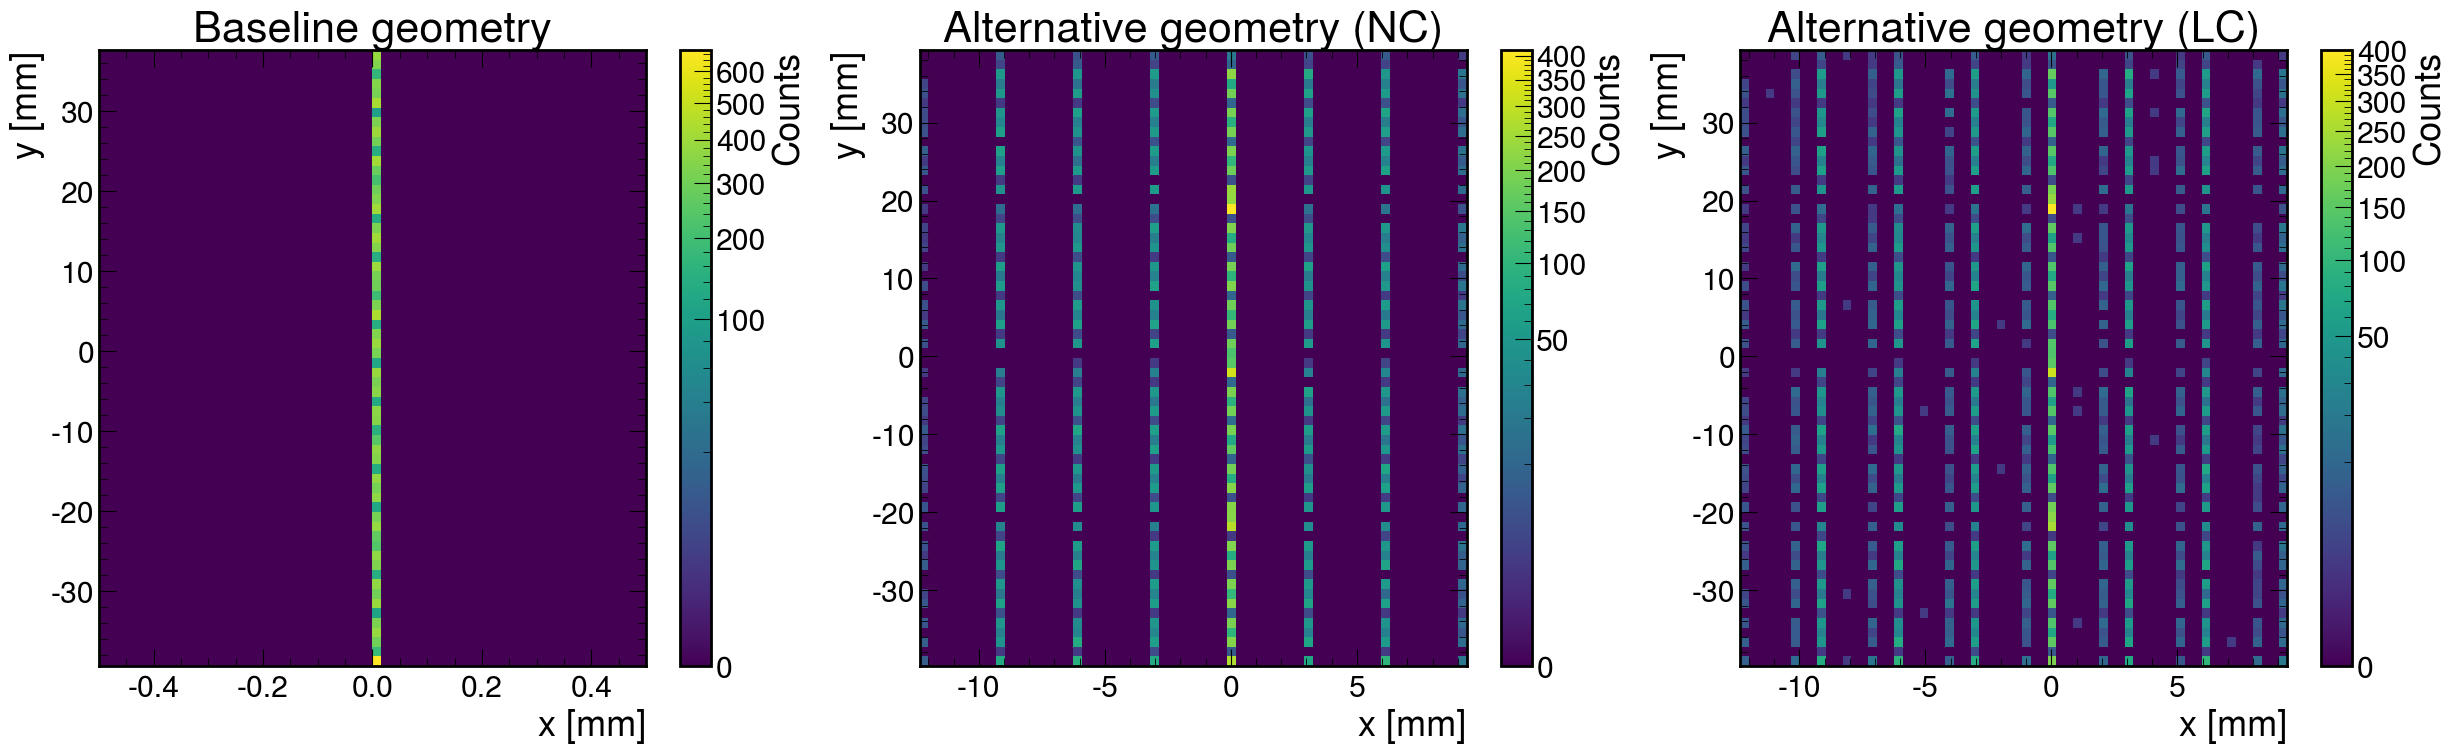

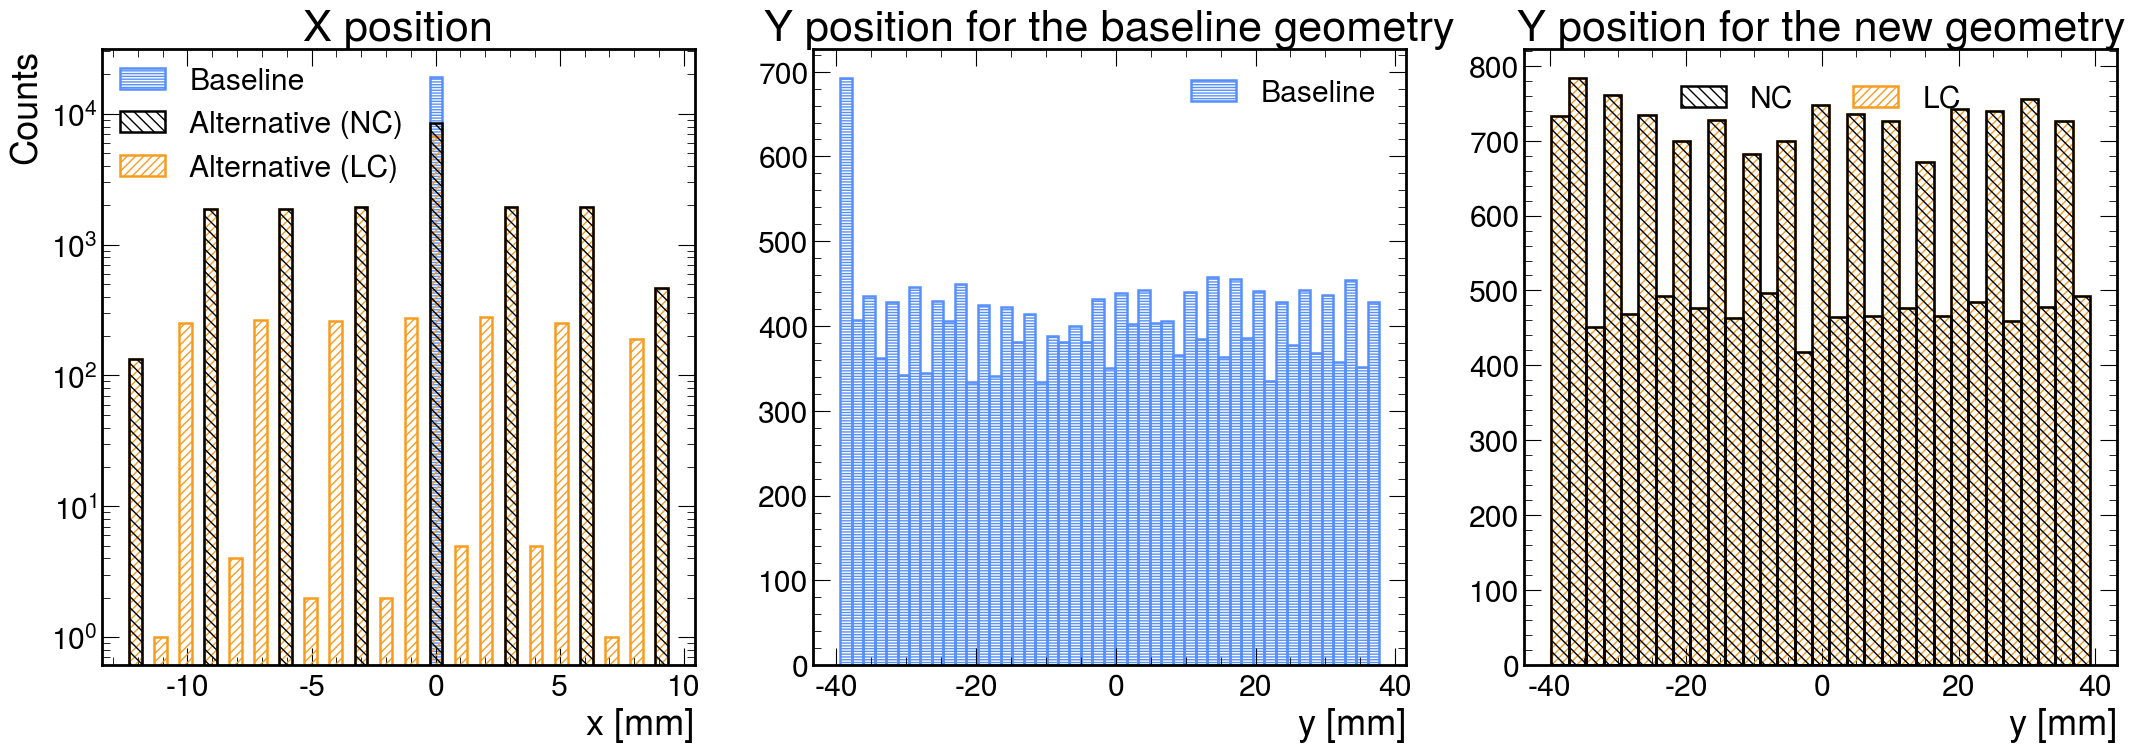

 max xc = -1.0


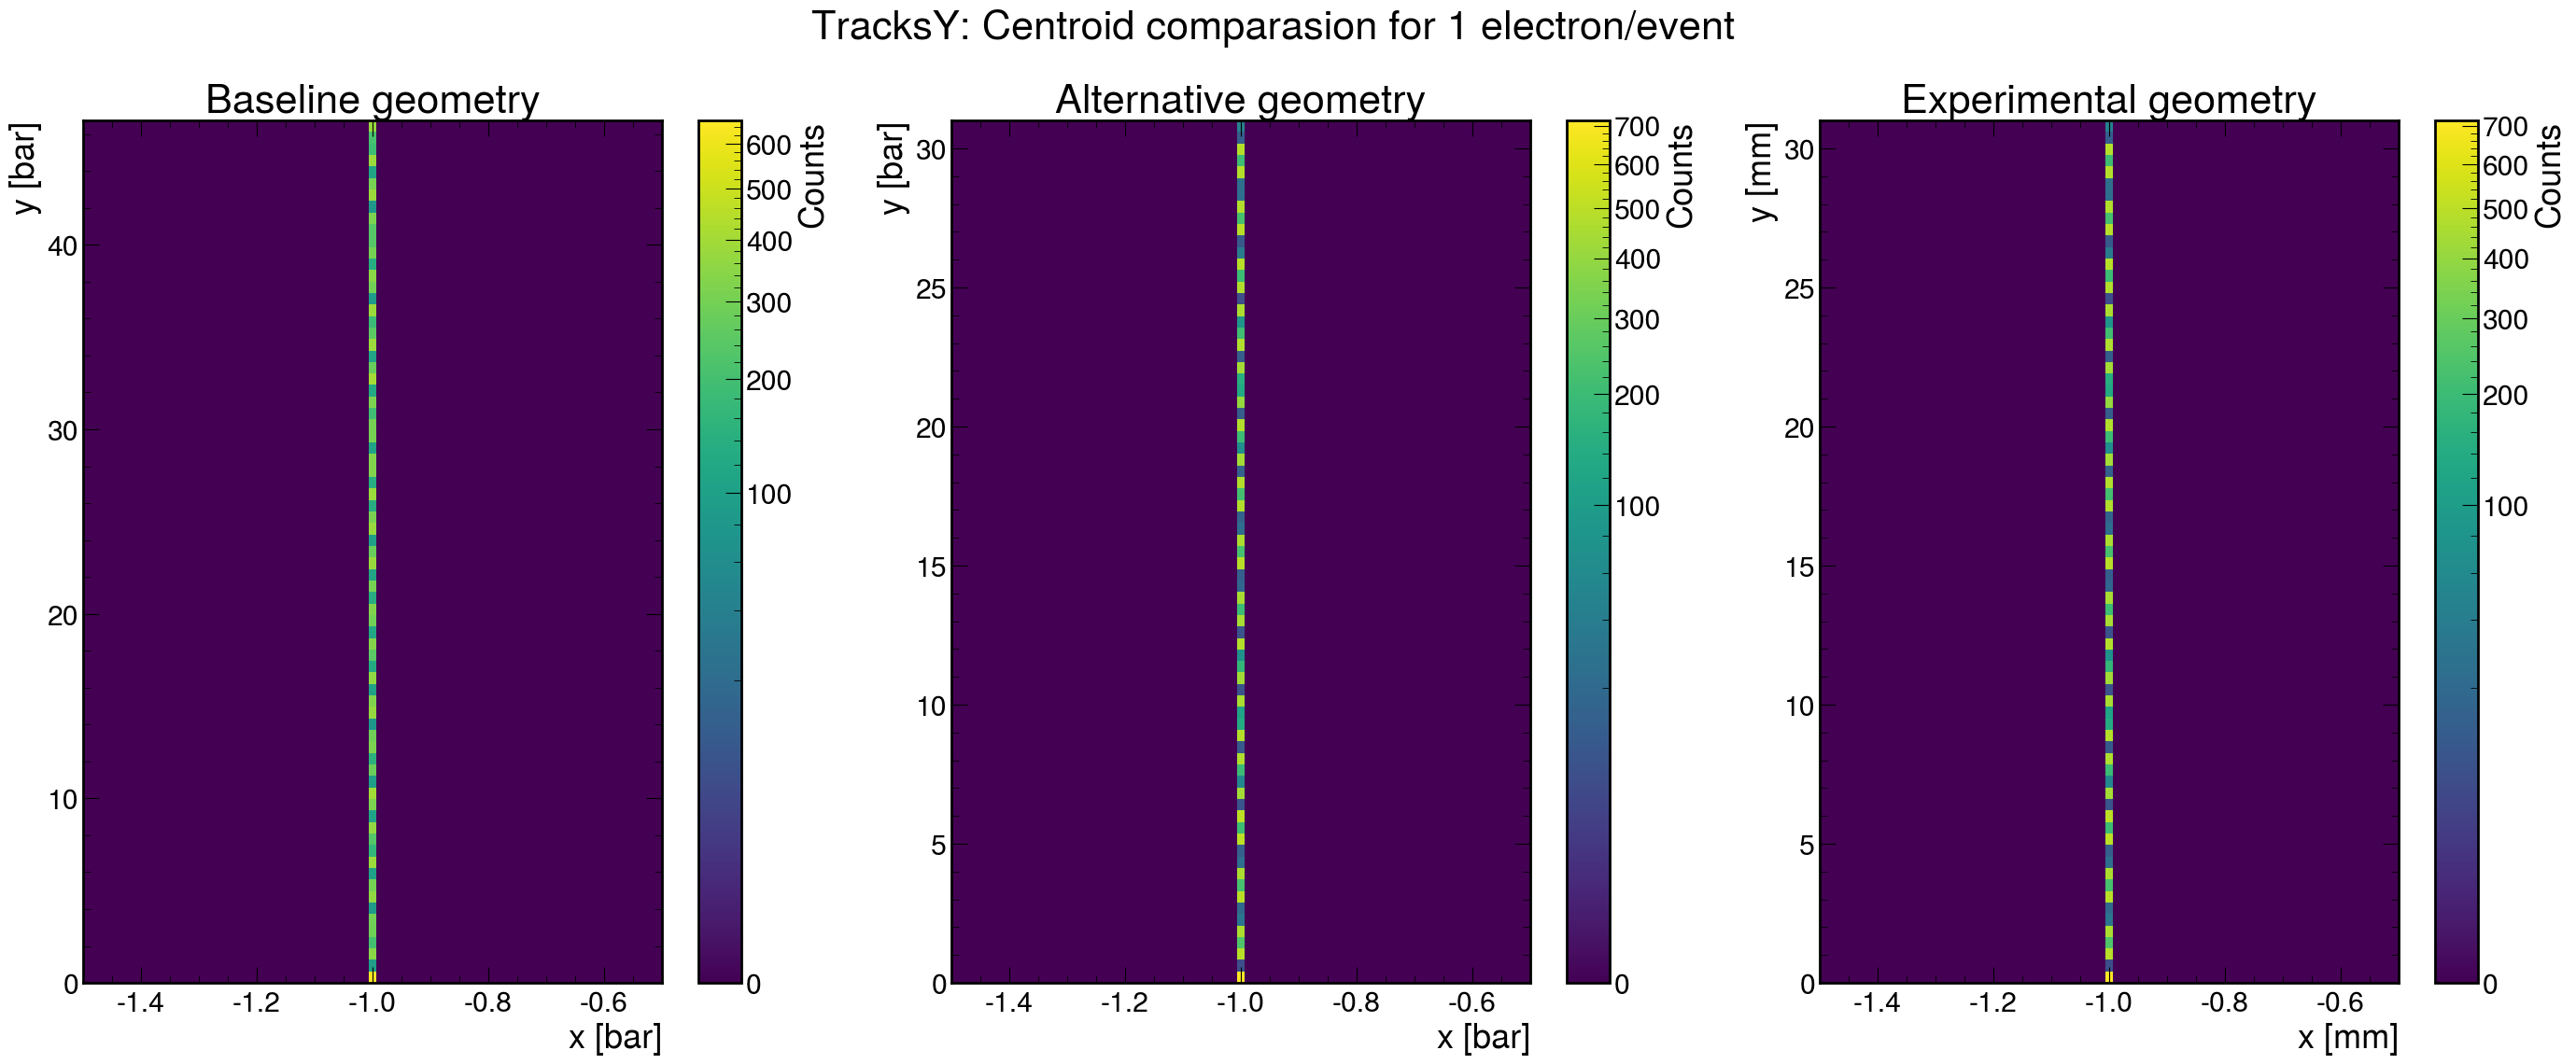

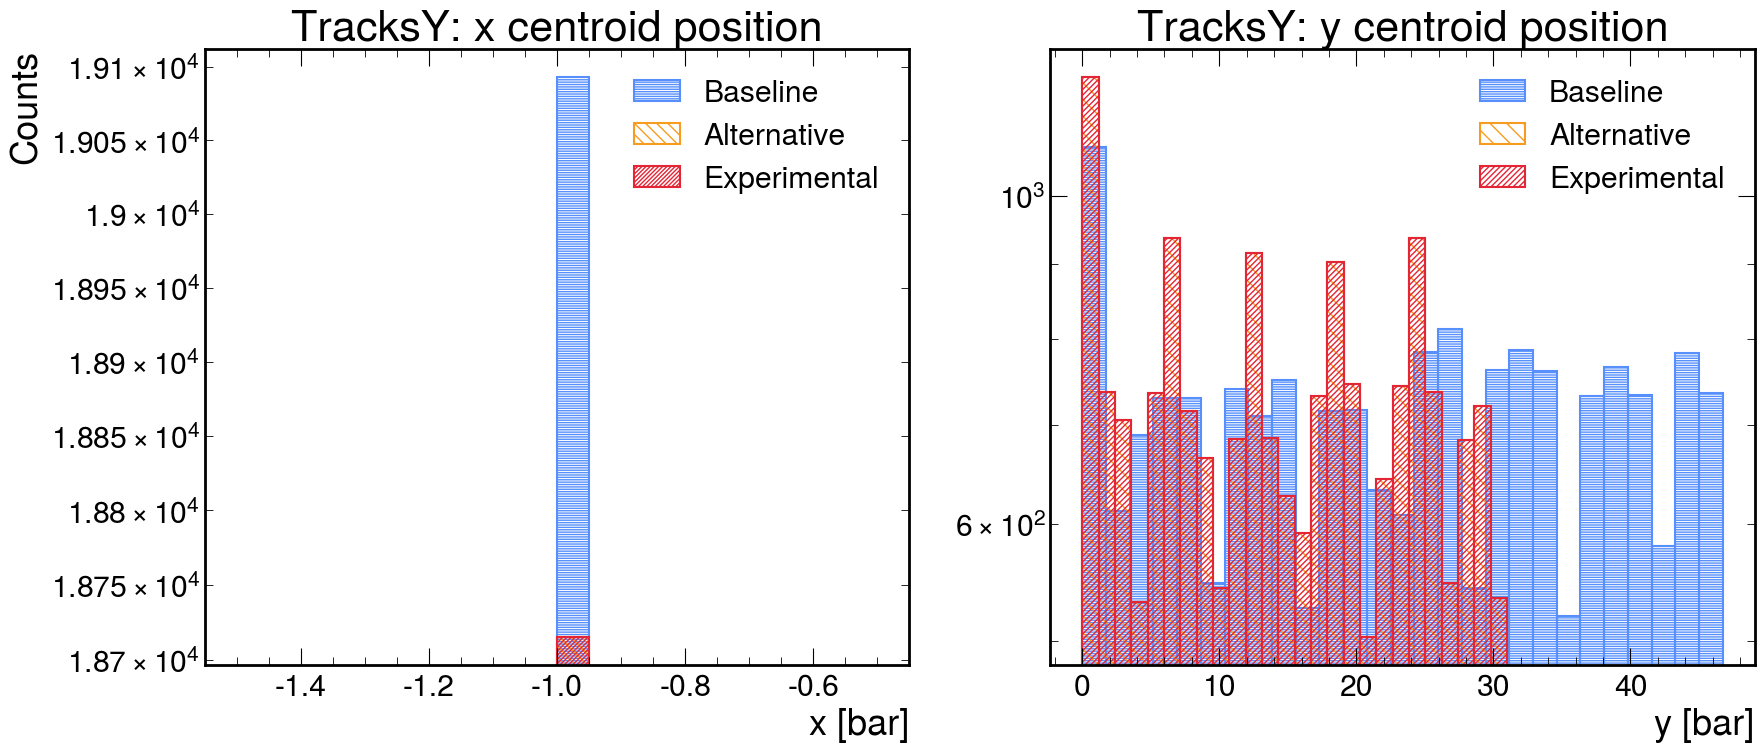

Alternative geometry before redution:  18715
Alternative geometry before redution, x_min:  1.55
Alternative geometry after redution 18715
Alternative geometry centroid:  18715


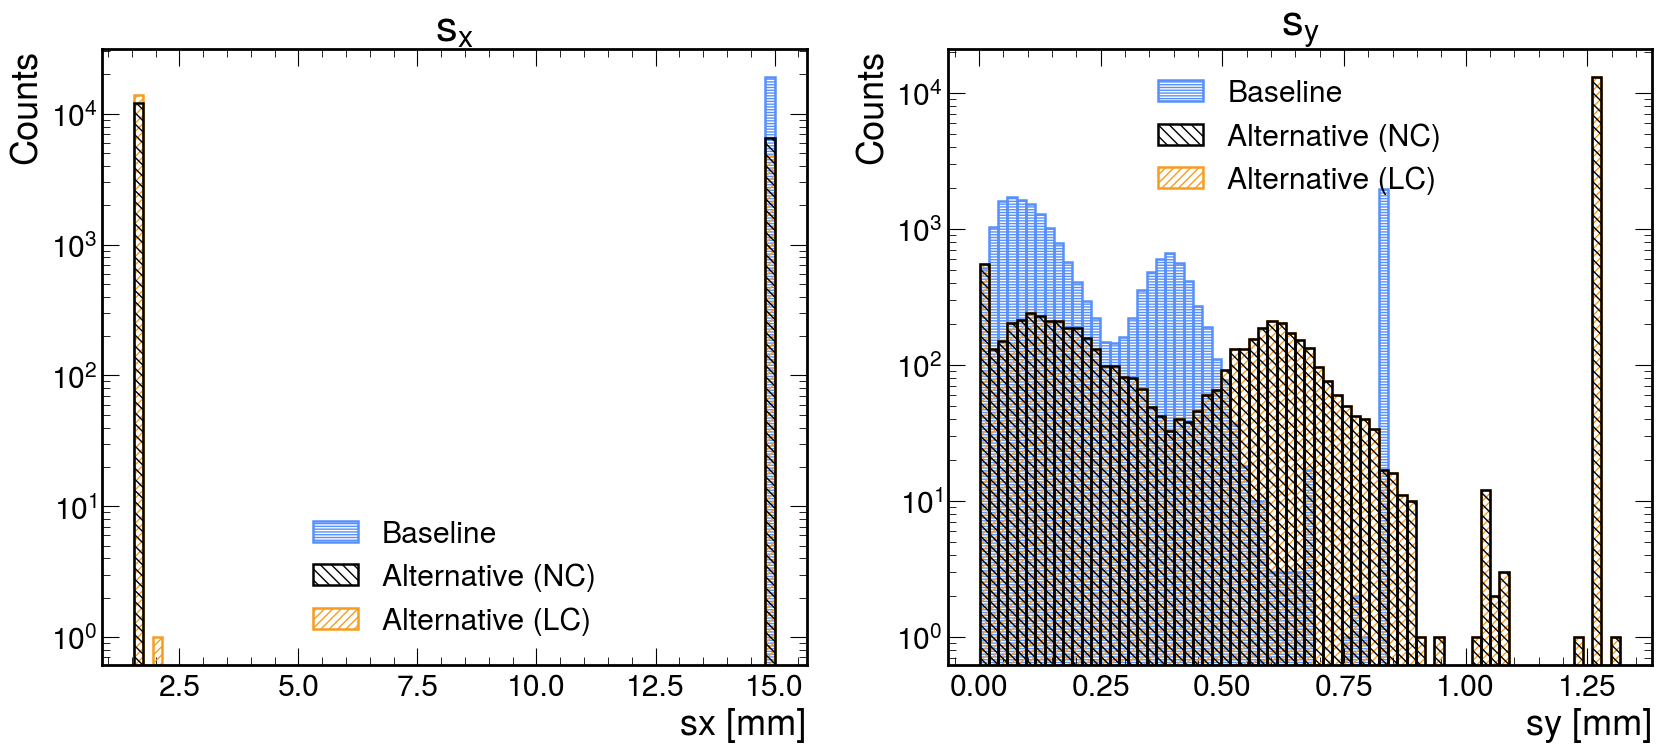

Baseline geometry: sx=(15.0,15.0) and sy=(0.0009884603787213564,0.824999988079071)
Alternative geometry: sx=(1.5499999523162842,15.0) and sy=(0.002757607027888298,1.3172695636749268)
Experimental geometry: sx=(1.5499999523162842,15.0) and sy=(0.002757607027888298,1.3172695636749268)

Alternative
sx>8: 6579; sx<8: 12136



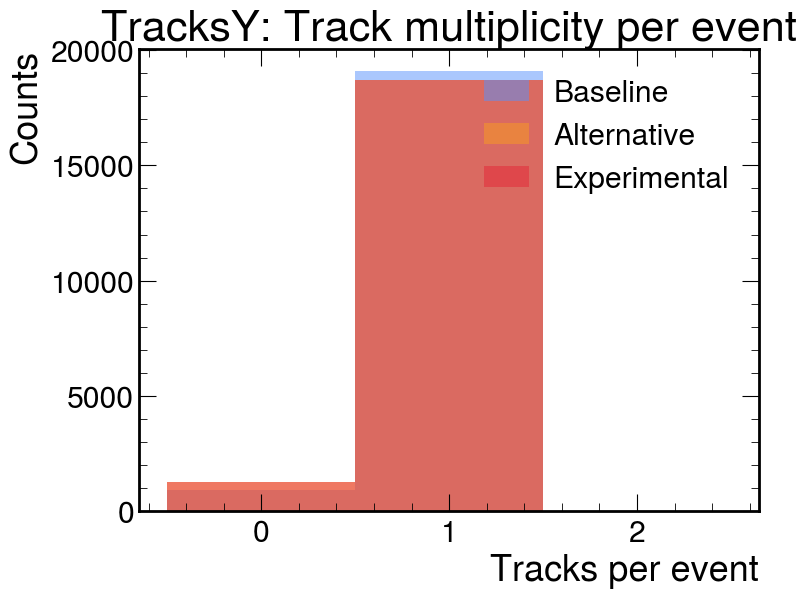

Number of 0-electron events:
- Baseline: 905, 4.526 % 
- Alternative: 1283, 6.416 %
- Experimental: 1283, 6.416 %
Number of 1-electron events:
- Baseline: 19091, 95.469 % 
- Alternative: 18715, 93.584 %
- Experimental: 18715, 93.584 %
Number of 2-electron events:
- Baseline: 1, 0.005 % 
- Alternative: 0, 0.000 %
- Experimental: 0, 0.000 %



In [ ]:
def flatten_tracks(ftr_pad): #test
    base = "TriggerPadTracksY_test/TriggerPadTracksY_test."
    
        # count tracks per event (this is your "w", but correct)
    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])

    x  = np.concatenate(ftr_pad[base + "x_"])
    y  = np.concatenate(ftr_pad[base + "y_"])
    z  = np.concatenate(ftr_pad[base + "z_"])
    xc = np.concatenate(ftr_pad[base + "centroid_x_"])
    yc = np.concatenate(ftr_pad[base + "centroid_y_"])
    sx = np.concatenate(ftr_pad[base + "sx_"])
    sy = np.concatenate(ftr_pad[base + "sy_"])
    c  = np.concatenate(ftr_pad[base + "centroid_"])

    return x, y, z, xc, yc, sx, sy, c, count

def flatten_tracks_(ftr_pad): #overlay
    base = "TriggerPadTracksY_overlay/TriggerPadTracksY_overlay."

    count = np.array([len(ev) for ev in ftr_pad[base + "centroid_"]])

    x  = np.concatenate(ftr_pad[base + "x_"])
    y  = np.concatenate(ftr_pad[base + "y_"])
    z  = np.concatenate(ftr_pad[base + "z_"])
    xc = np.concatenate(ftr_pad[base + "centroid_x_"])
    yc = np.concatenate(ftr_pad[base + "centroid_y_"])
    c  = np.concatenate(ftr_pad[base + "centroid_"])

    return x, y, z, xc, yc,sx, sy, c, count
    
x, y, z,xc,yc,sx,sy,c,count = flatten_tracks(Ytr) #ldmx-det-v14-8gev
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_ = flatten_tracks(Ytr_alt) #ldmx-vertTS-v14-8gev
#without deviation
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1 = flatten_tracks(Ytr_exp) 
#ldmx-vertTS-v14-8gev with deviation

#Change the function for overlay

print("Baseline geometry before redution: ",len(x))

print("Baseline geometry before redution, x_min: ",min(x))
# Update to eliminate "bad points"
mn = -50
y = y[y >= mn]
x = x[(x >=mn)]
print("Baseline geometry after redution", len(x))
print("Baseline geometry centroid: ",len(xc))

print("Alternative geometry before redution: ",len(x_))

print("Alternative geometry before redution, x_min: ",min(x_))
# Update to eliminate "bad points"
mn = -50
y_ = y_[y_ >= mn]
x_ = x_[(x_ >=mn) ]
print("Alternative geometry after redution", len(x_))
print("Alternative geometry centroid: ",len(xc_))

print("Experimental geometry before redution: ",len(x_1))

print("Experimental geometry before redution, x_min: ",min(x_1))
# Update to eliminate "bad points"
mn = -50
y_1 = y_1[y_1 >= mn]
x_1 = x_1[(x_1 >=mn) ]
print("Experimental geometry after redution", len(x_1))
print("Experimental geometry centroid: ",len(xc_1))

# 2D hit map (x-y position)
fig, axs = plt.subplots(1, 3, figsize=(30,8))

h0 = axs[0].hist2d(x, y, bins=(32*8)//4, norm=PowerNorm(gamma=0.3))
axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
axs[0].set_title("Baseline geometry")

h1 = axs[1].hist2d(x_, y_, bins=(32*8)//4, norm=PowerNorm(gamma=0.3))
axs[1].set_xlabel("x [mm]")
axs[1].set_ylabel("y [mm]")
axs[1].set_title("Alternative geometry (NC)")

h2 = axs[2].hist2d(x_1, y_1, bins=(32*8)//4, norm=PowerNorm(gamma=0.3))
axs[2].set_xlabel("x [mm]")
axs[2].set_ylabel("y [mm]")
axs[2].set_title("Alternative geometry (LC)")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")
fig.colorbar(h2[3], ax=axs[2], label="Counts")

plt.savefig('plots/1elec/TracksY_position2D',
            dpi=300, bbox_inches="tight")

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(26,8))
# ---- Left: original ----
min_ = min(min(x_),min(x_1))
max_ = max(max(x_),max(x_1))
bins=np.linspace(min_,max_,44)

axs[0].hist(x, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[0].hist(x_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='Alternative (NC)')

axs[0].hist(x_1, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='Alternative (LC)')

axs[0].set_xlabel("x [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"X position")
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.02,1.02))

min_ = min(y)
max_ = max(y)
bins=np.linspace(min_,max_,48)

axs[1].hist(y, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[1].set_xlabel("y [mm]")
axs[1].set_title(f"Y position for the baseline geometry")
axs[1].legend()

min_ = min(min(y_),min(y_1))
max_ = max(max(y_),max(y_1))
bins=np.linspace(min_,max_,32)

axs[2].hist(y_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8,
            alpha=1, zorder=3,
            label='NC')

axs[2].hist(y_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8,
            alpha=1, zorder=2,
            label='LC')

axs[2].set_xlabel("y [mm]")
axs[2].set_title(f"Y position for the new geometry")
axs[2].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2
)
# fig.suptitle("TracksY: Position comparasion for 1 electron/event")
plt.savefig('plots/1elec/TracksY_position', dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()

text=f""" max xc = {max(xc_)}"""
print(text)

# 2D hit map (x-y position) ------- Centroids --------------
fig, axs = plt.subplots(1, 3, figsize=(34,12))
fig.suptitle("TracksY: centroid position") #fontsize=18)
h0 = axs[0].hist2d(xc, yc, bins=75,norm=PowerNorm(gamma=0.3))
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("y [bar]")
axs[0].set_title(f"Baseline geometry")

h1 = axs[1].hist2d(xc_, yc_, bins=75 ,norm=PowerNorm(gamma=0.3))
axs[1].set_xlabel("x [bar]")
axs[1].set_ylabel("y [bar]")
axs[1].set_title(f"Alternative geometry")

h2 = axs[2].hist2d(xc_1, yc_1, bins=75,norm=PowerNorm(gamma=0.3))
axs[2].set_xlabel("x [mm]")
axs[2].set_ylabel("y [mm]")
axs[2].set_title(f"Experimental geometry")

fig.colorbar(h0[3], ax=axs[0], label="Counts")
fig.colorbar(h1[3], ax=axs[1], label="Counts")
fig.colorbar(h2[3], ax=axs[2], label="Counts")
fig.suptitle("TracksY: Centroid comparasion for 1 electron/event")

#plt.tight_layout() do not works with both
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20,8))

axs[0].hist(xc,  bins=20, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='-------', linewidth=1.5, label='Baseline')
axs[0].hist(xc_, bins=20, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='\\\\\\', linewidth=1.5, label='Alternative')
axs[0].hist(xc_1, bins=20, histtype='bar', facecolor='none',
            edgecolor='C2', hatch='////////', linewidth=1.5, label='Experimental')
axs[0].set_xlabel("x [bar]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"TracksY: x centroid position")
axs[0].legend()

axs[1].hist(yc,  bins='auto', histtype='bar', facecolor='none',
            edgecolor='C0', hatch='-------', linewidth=1.5, label='Baseline')
axs[1].hist(yc_, bins='auto', histtype='bar', facecolor='none',
            edgecolor='C1', hatch='\\\\', linewidth=1.5, label='Alternative')
axs[1].hist(yc_1, bins='auto', histtype='bar', facecolor='none',
            edgecolor='C2', hatch='//////', linewidth=1.5, label='Experimental')
axs[1].set_xlabel("y [bar]")
axs[1].set_yscale('log')
axs[1].set_title(f"TracksY: y centroid position")
axs[1].legend()

#plt.tight_layout()
plt.show()


print("Alternative geometry before redution: ",len(sx_))

print("Alternative geometry before redution, x_min: ",min(sx_))
# Update to eliminate "bad points"
mn = -50
sy_ = sy_[sy_ >= mn]
sx_ = sx_[(sx_ >=mn) ]
print("Alternative geometry after redution", len(sx_))
print("Alternative geometry centroid: ",len(sx_))


fig, axs = plt.subplots(1, 2, figsize=(20,8))

min_ = min(min(sx),min(sx_),min(sx_1))
max_ = max(max(sx),max(sx_),max(sx_1))
bins=np.linspace(min_,max_,70)
axs[0].hist(sx, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[0].hist(sx_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='Alternative (NC)')

axs[0].hist(sx_1, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='Alternative (LC)')
axs[0].set_xlabel("sx [mm]")
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title(f"$s_x$")
axs[0].legend()

min_ = min(min(sy),min(sy_),min(sy_1))
max_ = max(max(sy),max(sy_),max(sy_1))
bins=np.linspace(min_,max_,70)
axs[1].hist(sy, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C0', hatch='------', linewidth=1.8, alpha=1, zorder=1,
            label='Baseline')

axs[1].hist(sy_, bins=bins, histtype='bar', facecolor='none',
            edgecolor='black', hatch='\\\\\\', linewidth=1.8, alpha=1, zorder=3,
            label='Alternative (NC)')

axs[1].hist(sy_1, bins=bins, histtype='bar', facecolor='none',
            edgecolor='C1', hatch='////', linewidth=1.8, alpha=1, zorder=2,
            label='Alternative (LC)')
axs[1].set_xlabel("sy [mm]")
axs[1].set_ylabel("Counts")
axs[1].set_yscale('log')
axs[1].set_title(f"$s_y$")
axs[1].legend()

plt.savefig('plots/1elec/TracksY_uncertainty', dpi=300, bbox_inches="tight")
#plt.tight_layout()
plt.show()

text= f"""Baseline geometry: sx=({min(sx)},{max(sx)}) and sy=({min(sy)},{max(sy)})
Alternative geometry: sx=({min(sx_)},{max(sx_)}) and sy=({min(sy_)},{max(sy_)})
Experimental geometry: sx=({min(sx_1)},{max(sx_1)}) and sy=({min(sy_1)},{max(sy_1)})

Alternative
sx>8: {np.sum(sx_>8)}; sx<8: {np.sum(sx_<8)}
"""

print(text)

max_count = int(max(count.max(), count_.max()))
bins = np.arange(-0.5, max_count + 1.5, 1)

# Plot
plt.figure(figsize=(8,6))

plt.hist(count,  bins=bins, alpha=0.5, label='Baseline')#,density=True)
plt.hist(count_, bins=bins, alpha=0.5, label='Alternative')#,density=True)
plt.hist(count_1, bins=bins, alpha=0.5, label='Experimental')#,density=True)


plt.xlabel("Tracks per event")
plt.ylabel("Counts")
# plt.yscale('log')
plt.title("TracksY: Track multiplicity per event")
plt.legend()

plt.show()

text = f"""Number of 0-electron events:
- Baseline: {np.sum(count == 0)}, {np.sum(count==0)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 0)}, {np.sum(count_==0)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 0)}, {np.sum(count_1==0)*100/len(count_1):.3f} %
Number of 1-electron events:
- Baseline: {np.sum(count == 1)}, {np.sum(count==1)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 1)}, {np.sum(count_==1)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 1)}, {np.sum(count_1==1)*100/len(count_1):.3f} %
Number of 2-electron events:
- Baseline: {np.sum(count == 2)}, {np.sum(count==2)*100/len(count):.3f} % 
- Alternative: {np.sum(count_ == 2)}, {np.sum(count_==2)*100/len(count_):.3f} %
- Experimental: {np.sum(count_1 == 2)}, {np.sum(count_1==2)*100/len(count_1):.3f} %
"""



print(text)

Again, a couple of examples of things I look for into the arrays.

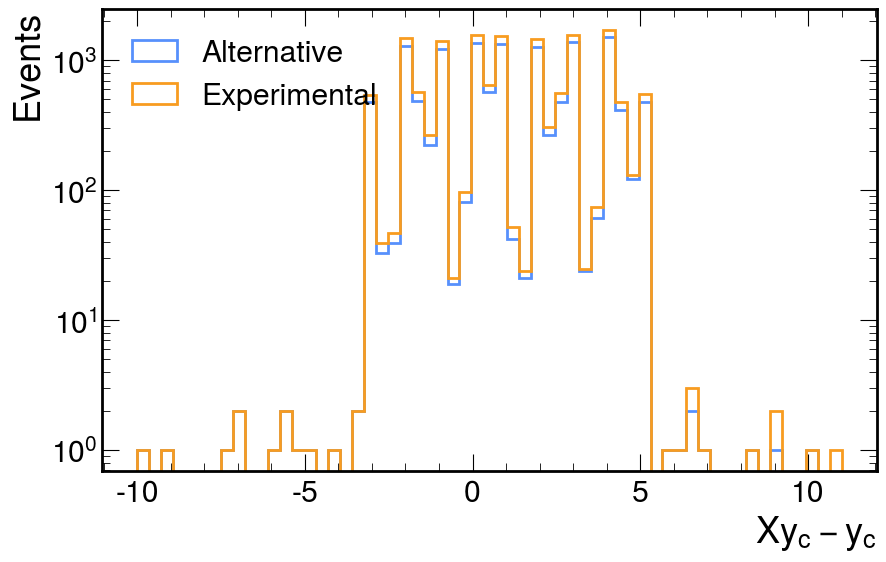

In [27]:
def one_track_values(values, counts):
    starts = np.cumsum(np.r_[0, counts[:-1]])
    valid = (counts == 1) & (starts < len(values))
    return values[starts[valid]], valid


# Get one-track yc values independently
yc_alt, mask_y_alt = one_track_values(yc, count_)
Xyc_alt, mask_X_alt = one_track_values(Xyc_, Xcount_)

yc_exp, mask_y_exp = one_track_values(yc_1, count_1)
Xyc_exp, mask_X_exp = one_track_values(Xyc_1, Xcount_1)


# Keep only events where BOTH normal and X have count = 1
event_mask_alt = mask_y_alt & mask_X_alt
event_mask_exp = mask_y_exp & mask_X_exp

# Re-extract using the common event masks
starts_y_alt = np.cumsum(np.r_[0, count_[:-1]])
starts_X_alt = np.cumsum(np.r_[0, Xcount_[:-1]])

starts_y_exp = np.cumsum(np.r_[0, count_1[:-1]])
starts_X_exp = np.cumsum(np.r_[0, Xcount_1[:-1]])

diff_alt = Xyc_[starts_X_alt[event_mask_alt]] - yc_[starts_y_alt[event_mask_alt]]
diff_exp = Xyc_1[starts_X_exp[event_mask_exp]] - yc_1[starts_y_exp[event_mask_exp]]


# Histogram
bins = np.linspace(
    min(diff_alt.min(), diff_exp.min()),
    max(diff_alt.max(), diff_exp.max()),
    60
)

plt.figure(figsize=(10,6))

plt.hist(diff_alt, bins=bins, histtype="step", linewidth=2, label="Alternative")
plt.hist(diff_exp, bins=bins, histtype="step", linewidth=2, label="Experimental")

plt.xlabel(r"$Xy_c - y_c$")
plt.ylabel("Events")
plt.yscale("log")
plt.legend()

plt.show()

In [8]:
x, y, z,xc,yc,sx,sy,c,count = flatten_tracks(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_ = flatten_tracks(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1 = flatten_tracks(Ytr_exp)

text = f""" - Baseline geometry
sx={np.mean(sx):.2f}
sy={np.mean(sy):.2f}

 - Alternative geometry
sx={np.mean(sx_):.2f}
sy={np.mean(sy_):.2f}

 - Experimental geometry
sx={np.mean(sx_1):.2f}
sy={np.mean(sy_1):.2f}
"""
print(text)

 - Baseline geometry
sx=15.00
sy=0.24

 - Alternative geometry
sx=6.28
sy=0.99

 - Experimental geometry
sx=4.99
sy=0.99



In [ ]:
x, y, z,xc,yc,sx,sy,c,count = flatten_tracks(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_ = flatten_tracks(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1 = flatten_tracks(Ytr_exp)

# Build event ids
event_id   = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_  = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

diff_events = []

start_ = 0
start_1 = 0

for i, (n0, n1) in enumerate(zip(count_, count_1)):
    y_evt_  = y_[start_:start_+n0]
    y_evt_1 = y_1[start_1:start_1+n1]

    # mark event if different (also catches different lengths)
    if (len(y_evt_) != len(y_evt_1)) or (not np.allclose(y_evt_, y_evt_1)):
        diff_events.append(i)

    start_  += n0
    start_1 += n1

diff_events = np.array(diff_events)

track_mask_  = np.isin(event_id_, diff_events)
track_mask_1 = np.isin(event_id_1, diff_events)

event_id_  = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]

text = f"""
 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}
"""
print(text)


 - Alternative geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Experimental geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]



In [ ]:
x, y, z,xc,yc,sx,sy,c,count = flatten_tracks(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_ = flatten_tracks(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1 = flatten_tracks(Ytr_exp)

event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])

target_event = 19980  
event_mask  = (event_id  == target_event)
event_mask_ = (event_id_ == target_event)
event_mask_1 = (event_id_1 == target_event)

track_mask  = event_mask
track_mask_ = event_mask_
track_mask_1 = event_mask_1

event_id  = event_id[track_mask]
event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]

# Apply
x, y, z, xc, yc, sx, sy, c = [arr[track_mask]  for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]

text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id}\nx: {x}\ny: {y}\nxc: {xc}\nyc: {yc}\nsx: {sx}\nsy:{sy}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}
"""
print(text)

 - Baseline geometry
Length of values: 1
event_id: [19980]
x: [0.]
y: [-23.628733]
xc: [-1.]
yc: [9.588645]
sx: [15.]
sy:[0.0090703]

 - Alternative geometry
Length of values: 1
event_id: [19980]
x: [0.]
y: [-0.50743866]
xc: [-1.]
yc: [15.38924]
sx: [15.]
sy:[0.7019494]

 - Experimental geometry
Length of values: 1
event_id: [19980]
x: [0.]
y: [-0.50743866]
xc: [-1.]
yc: [15.38924]
sx: [15.]
sy:[0.7019494]



In [28]:
x, y, z,xc,yc,sx,sy,c,count = flatten_tracks(Ytr)
x_, y_, z_,xc_,yc_,sx_,sy_,c_,count_ = flatten_tracks(Ytr_alt)
x_1, y_1, z_1,xc_1,yc_1,sx_1,sy_1,c_1,count_1 = flatten_tracks(Ytr_exp)

# Build event mask
event_mask  = (count  == 2)
event_mask_ = (count_ == 2)
event_mask_1 = (count_1 == 2)
event_id  = np.concatenate([np.full(n, i) for i, n in enumerate(count)])
event_id_ = np.concatenate([np.full(n, i) for i, n in enumerate(count_)])
event_id_1 = np.concatenate([np.full(n, i) for i, n in enumerate(count_1)])
# Expand to track-level mask
track_mask  = np.concatenate([np.full(n, m) for n, m in zip(count,  event_mask)])
track_mask_ = np.concatenate([np.full(n, m) for n, m in zip(count_, event_mask_)])
track_mask_1 = np.concatenate([np.full(n, m) for n, m in zip(count_1, event_mask_1)])
event_id  = event_id[track_mask]
event_id_ = event_id_[track_mask_]
event_id_1 = event_id_1[track_mask_1]
# Apply
x, y, z, xc, yc, sx, sy, c = [arr[track_mask]  for arr in (x, y, z, xc, yc, sx, sy, c)]
x_, y_, z_, xc_, yc_, sx_, sy_, c_ = [arr[track_mask_] for arr in (x_, y_, z_, xc_, yc_, sx_, sy_, c_)]
x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1 = [arr[track_mask_1] for arr in (x_1, y_1, z_1, xc_1, yc_1, sx_1, sy_1, c_1)]


text = f""" - Baseline geometry
Length of values: {len(x)}\nevent_id: {event_id}\nx: {x}\ny: {y}\nxc: {xc}\nyc: {yc}\nsx: {sx}\nsy:{sy}

 - Alternative geometry
Length of values: {len(x_)}\nevent_id: {event_id_}\nx: {x_}\ny: {y_}\nxc: {xc_}\nyc: {yc_}\nsx: {sx_}\nsy:{sy_}

 - Experimental geometry
Length of values: {len(x_1)}\nevent_id: {event_id_1}\nx: {x_1}\ny: {y_1}\nxc: {xc_1}\nyc: {yc_1}\nsx: {sx_1}\nsy:{sy_1}
"""
print(text)


 - Baseline geometry
Length of values: 2
event_id: [18450 18450]
x: [0. 0.]
y: [11.509453 14.382027]
xc: [-1. -1.]
yc: [30.884516 32.62547 ]
sx: [15. 15.]
sy:[0.78009164 0.46501336]

 - Alternative geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

 - Experimental geometry
Length of values: 0
event_id: []
x: []
y: []
xc: []
yc: []
sx: []
sy:[]

